# Benchmarking and Evaluation

## Prepare Environment

Set up the notebook environment with necessary imports and create reusable utility functions for tasks we'll repeat across all datasets.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
import copy
import numpy as np
import pandas as pd
from scipy.stats import iqr
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.linear_model import Ridge

import utils
from sgkan import sgkan_parameter_search as sps
from sgkan import sgkan_model
from hkan.hkan import (
    Sigmoid, Gaussian, ReLU, Tanh, Softplus, Identity,
)
import visualize
import swim as ss
import evaluation_metrics as em
random_seed = 0

/Users/gizemnurdal/miniconda3/envs/swim-meets-kans/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Helper functions for data handling, model evaluation, and statistical analysis across multiple runs.

In [2]:
def create_export_seed_results(seed_results, name):
    """Create dataframe from the seed results."""
    rows = []
    for i, r in enumerate(seed_results):
        rows.append({
            "seed": i,
            "train_mae": r["train"]["mae"],
            "train_rmse": r["train"]["rmse"],
            "train_inference_time_secs": r["train"]["inference_time_secs"],
            "test_mae": r["test"]["mae"],
            "test_rmse": r["test"]["rmse"],
            "test_inference_time_secs": r["test"]["inference_time_secs"],
        })

    seed_results_df = pd.DataFrame(rows)
    seed_results_df.to_csv(f"data/{name}.csv", index=False)
    return seed_results_df

def summarize_metrics(df, name):
    """Calculate IQR and Median values of RMSE and MAE metrics."""
    summary = {
        "model": name,
        "train_rmse_median": df["train_rmse"].median(),
        "train_rmse_iqr": iqr(df["train_rmse"]),
        "test_rmse_median": df["test_rmse"].median(),
        "test_rmse_iqr": iqr(df["test_rmse"]),
    }
    return summary


In [3]:
def run_sgkan_seed_experiments(x_train, y_train, x_test, y_test, layer_configs, n_runs=50):
    """Train SGKAN model n_runs times with different random seeds."""
    n_runs_results = []
    for s in range(n_runs):
        print(f"Seed: {s}")
        updated_configs = [config.copy() for config in layer_configs]
        for config in updated_configs:
            config['seed'] = s
        
        model = sgkan_model.SGKANModel(updated_configs).fit(x_train, y_train)
        results = em.evaluate(model, x_train, y_train, x_test, y_test)
        n_runs_results.append(results)
    
    return n_runs_results

In [4]:
def plot_hypothesis_1_results(results_df):
    """Plot Hypothesis 1 comparison results for SGKAN (swim), SGKAN (random), and HKAN."""
    plt.figure(figsize=(12, 6))

    plt.plot(results_df['layer_width'], results_df['sgkan_swim_train_rmse'], marker='o', label='SGKAN SWIM Train', color='#1f77b4')
    plt.plot(results_df['layer_width'], results_df['sgkan_swim_test_rmse'], marker='s', label='SGKAN SWIM Test', color='#1f77b4', linestyle='--')

    plt.plot(results_df['layer_width'], results_df['sgkan_random_train_rmse'], marker='o', label='SGKAN Random Train', color='#ff7f0e')
    plt.plot(results_df['layer_width'], results_df['sgkan_random_test_rmse'], marker='s', label='SGKAN Random Test', color='#ff7f0e', linestyle='--')

    plt.plot(results_df['layer_width'], results_df['hkan_train_rmse'], marker='o', label='HKAN Train', color='#2ca02c')
    plt.plot(results_df['layer_width'], results_df['hkan_test_rmse'], marker='s', label='HKAN Test', color='#2ca02c', linestyle='--')

    plt.xlabel('Layer Width')
    plt.ylabel('RMSE')
    plt.xscale('log')
    plt.yscale('log')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

def plot_first_layer_local_edge_r2_summary(layer_neurons):
    """
    Boxplot of train-local R^2 across all nodes q, one box per input p,
    for the FIRST layer only. Unlike plot_first_layer_featurewise_r2_summary
    (which scores each edge against the full y_train), this scores each
    edge only against the local points it was actually fit on.
    """
    neurons = layer_neurons[0]
    n_vars_out = len(neurons)
    n_vars_in = len(neurons[0]["edge_params"])

    data, labels = [], []
    for p in range(n_vars_in):
        r2_vals = [
            r2_score(neurons[q]["edge_params"][p]["local_y"],
                     neurons[q]["edge_params"][p]["local_pred"])
            for q in range(n_vars_out)
        ]
        data.append(r2_vals)
        labels.append(f"p={p}")

    _, ax = plt.subplots(figsize=(1.5 * n_vars_in + 2, 4))
    ax.boxplot(data, tick_labels=labels, showmeans=True)
    ax.set_title(f"Layer 1: Local R² distribution per input variable ({n_vars_out} nodes)")
    ax.set_ylabel(r"$R^2$ (local)")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8)
    plt.tight_layout()
    plt.show()

In [5]:
def load_dataset(dataset_prefix: str):
    """Load dataset using dataset prefix."""
    # base data directory
    DATA_DIR = os.path.join(os.getcwd(), "data")
    # load train and test set
    trn = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_trn.csv", delimiter=",")
    tst = np.loadtxt(f"{DATA_DIR}/{dataset_prefix.upper()}_tst.csv", delimiter=",")
    # slice train and test set
    x_train, y_train = trn[:, :-1], trn[:, -1]
    x_test,  y_test  = tst[:, :-1], tst[:, -1]
    
    print("x_train shape:", x_train.shape)
    print("y_train shape:", y_train.shape)
    print("x_test shape:", x_test.shape)
    print("y_test shape:", y_test.shape)

    return x_train, x_test, y_train, y_test

tf1_x_train, tf1_x_test, tf1_y_train, tf1_y_test = load_dataset("tf1")
tf2_x_train, tf2_x_test, tf2_y_train, tf2_y_test = load_dataset("tf2")
tf3_x_train, tf3_x_test, tf3_y_train, tf3_y_test = load_dataset("tf3")
tf4_x_train, tf4_x_test, tf4_y_train, tf4_y_test = load_dataset("tf4")
tf5_x_train, tf5_x_test, tf5_y_train, tf5_y_test = load_dataset("tf5")

x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)
x_train shape: (3750, 10)
y_train shape: (3750,)
x_test shape: (1250, 10)
y_test shape: (1250,)
x_train shape: (5000, 2)
y_train shape: (5000,)
x_test shape: (10000, 2)
y_test shape: (10000,)


## TF1

For TF1, we'll find the best SGKAN configuration through hyperparameter optimization, then run a robustness test with 50 random seeds to compare against our HKAN reproduction, configured with the paper's best reported hyperparameters. We'll also explore how layer width impacts performance and which input features matter most.

### Sanity Check

Sanity check that the model runs without errors. This serves as a basic test before moving to optimization and comparison experiments.

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=100, D_in=2)
[fit_layer] local-window method counts over 200 edges: {'interval_capped': 114, 'interval': 78, 'knn_fallback': 8}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=100)
[fit_layer] local-window method counts over 100 edges: {'interval': 70, 'interval_capped': 27, 'knn_fallback': 3}
TF1 SGKAN train R2: 0.9917611014507293


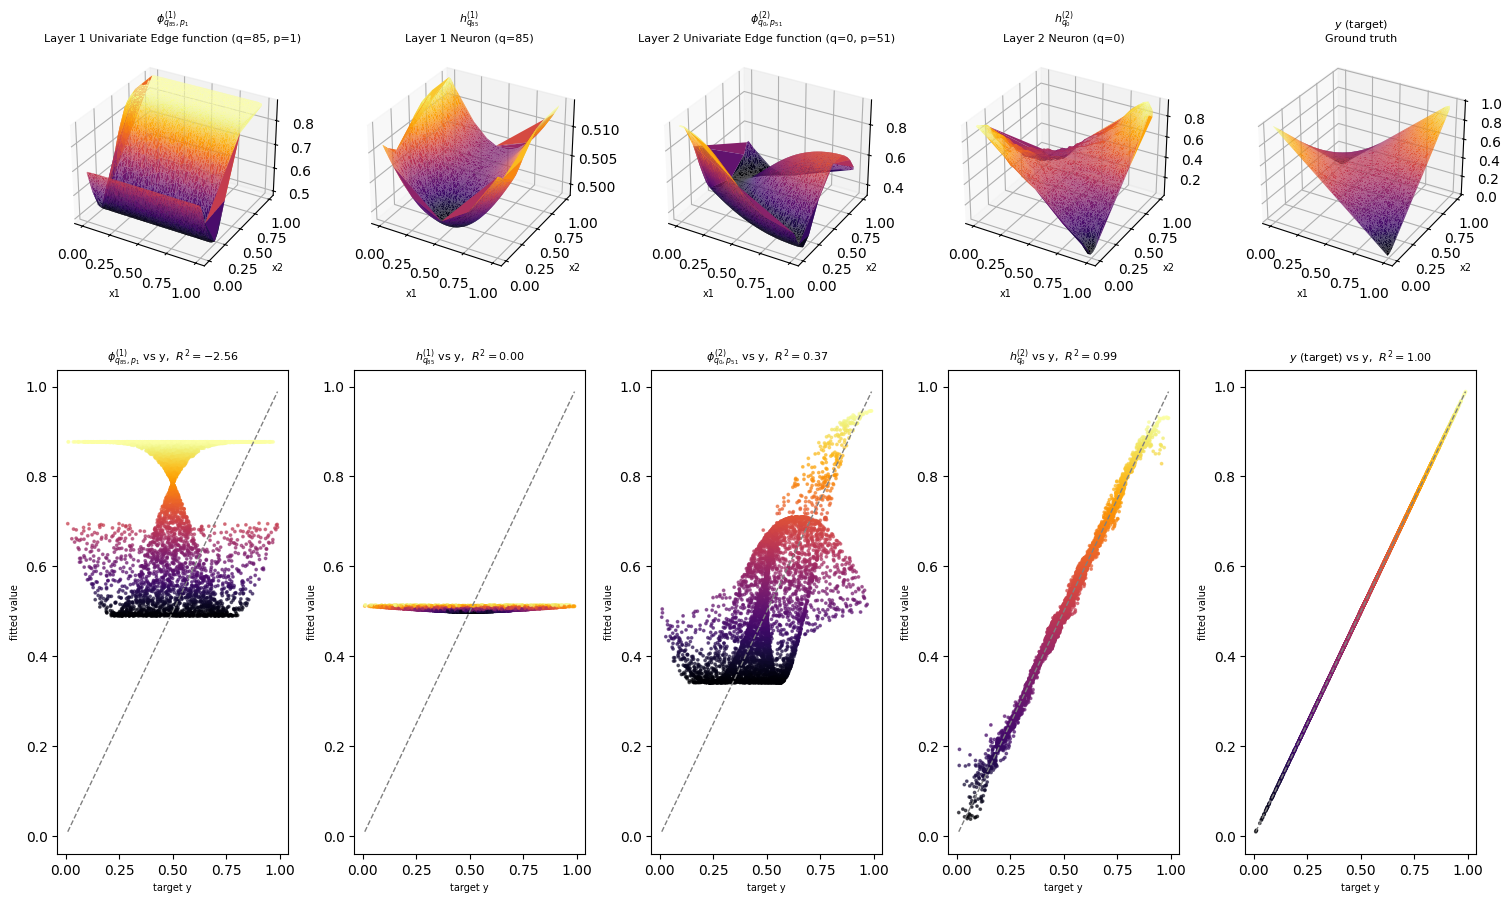

In [6]:
tf1_sgkan_layer_swim_configs = [
    {"layer_width": 100, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
]
# A stage item in stages list consists of (layer_idx, phi[q, p, :] edge function results, layer_output) 
tf1_sgkan_stages, tf1_sgkan_ytrain_hat, tf1_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf1_x_train, tf1_y_train, tf1_sgkan_layer_swim_configs)
print("TF1 SGKAN train R2:", r2_score(tf1_y_train, tf1_sgkan_ytrain_hat))

visualize.plot_model_stages(tf1_x_train, tf1_y_train, tf1_sgkan_stages, block_idx="random", seed=0)

In [7]:
tf1_sgkan_model = sgkan_model.SGKANModel(tf1_sgkan_layer_swim_configs).fit(tf1_x_train, tf1_y_train)

tf1_sgkan_results = em.evaluate(
    tf1_sgkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)
em.print_results(tf1_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=100, D_in=2)
[fit_layer] local-window method counts over 200 edges: {'interval_capped': 114, 'interval': 78, 'knn_fallback': 8}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=100)
[fit_layer] local-window method counts over 100 edges: {'interval': 70, 'interval_capped': 27, 'knn_fallback': 3}
[SGKANModel.fit] Total fit duration: 5.0470s
Metric          Train                Test                
-------------------------------------------------------
MAE             1.089213e-02         1.157665e-02        
RMSE            1.509684e-02         1.696069e-02        
-------------------------------------------------------
Inference (s)   1.231945             3.414247            


### Optuna - Parameter Search 

Find the best layer configuration for TF1 dataset.

In [8]:
tf1_result = sps.study_optuna_sgkan(
    "tf1", tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test,
    n_trials=375
)

Results found for tf1. Loading from data/tf1_sgkan_optuna_search.csv
Best Validation RMSE:   0.000000000019718
Best Test RMSE:          0.000000000166345
Best layer_width:        1000
Best num_inducing:       50
Best alpha_edge:         1.000e+01
Best alpha_neuron:       0.000e+00
Best kernel_type:        rbf

All 375 trials:
     number             value  params_layer_width  params_num_inducing  params_alpha_edge  params_alpha_neuron params_kernel_type          val_rmse     test_rmse
0         0  6.7783242464e-05                1000                   50              0.001                    0             matern  6.7783242464e-05           NaN
1         1  5.6343439768e-02                1000                   25              1.000                    0           periodic  5.6343439768e-02           NaN
2         2  1.4776349045e-06                 500                   50             10.000                    0                rbf  1.4776349045e-06           NaN
3         3  5.732019730

In [9]:
# Use best parameter configuration to fit an SGKAN model again
best_tf1_configs = tf1_result["layer_configs"]

In [97]:
tf1_sgkan_optuna_df = pd.read_csv("data/tf1_sgkan_optuna_search.csv")
tf1_sgkan_optuna_df.sort_values("val_rmse").head(10)

,number,value,datetime_start,datetime_complete,duration,params_alpha_edge,params_alpha_neuron,params_kernel_type,params_layer_width,params_num_inducing,...,fit_duration_sec,kernel_type,user_attrs_layer_width,user_attrs_num_inducing,sigma_scale,val_rmse,system_attrs_grid_id,system_attrs_search_space,state,test_rmse
321,321,1.9718027054e-11,2026-08-06 15:00:30.665284,2026-08-06 15:00:50.975097,20.309813,10.0,0,rbf,1000,50,...,19.114862333,rbf,1000,50,1,1.9718027054e-11,321,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,0.0000000002
207,207,5.4813087171e-11,2026-08-06 14:38:20.330624,2026-08-06 14:38:37.604884,17.274260,1.0,0,rbf,1000,50,...,16.017670875,rbf,1000,50,1,5.4813087171e-11,207,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
254,254,9.7881640041e-11,2026-08-06 14:47:21.200069,2026-08-06 14:47:31.224114,10.024045,10.0,0,rbf,1000,25,...,9.179296000,rbf,1000,25,1,9.7881640041e-11,254,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
363,363,6.0005247809e-10,2026-08-06 15:08:44.622213,2026-08-06 15:08:57.881550,13.259337,1.0,0,rbf,750,50,...,12.383522542,rbf,750,50,1,6.0005247809e-10,363,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
83,83,7.0983632996e-10,2026-08-06 14:16:56.022367,2026-08-06 14:17:29.504933,33.482566,10.0,0,rbf,1000,100,...,31.325037375,rbf,1000,100,1,7.0983632996e-10,83,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
305,305,1.6567754100e-09,2026-08-06 14:57:36.145585,2026-08-06 14:57:41.769204,5.623619,10.0,0,rbf,1000,10,...,5.090786791,rbf,1000,10,1,1.6567754100e-09,305,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
6,6,2.1652957075e-09,2026-08-06 14:00:48.891094,2026-08-06 14:01:24.617614,35.726520,1.0,0,rbf,1000,100,...,33.391136083,rbf,1000,100,1,2.1652957075e-09,6,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
370,370,2.6612455195e-09,2026-08-06 15:09:32.870993,2026-08-06 15:09:58.643458,25.772465,10.0,0,rbf,1000,75,...,24.096895709,rbf,1000,75,1,2.6612455195e-09,370,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
64,64,2.7290326661e-09,2026-08-06 14:13:07.031479,2026-08-06 14:13:12.009842,4.978363,1.0,0,rbf,1000,10,...,4.718459125,rbf,1000,10,1,2.7290326661e-09,64,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
145,145,2.8717483189e-09,2026-08-06 14:27:35.291063,2026-08-06 14:27:40.223432,4.932369,0.1,0,rbf,1000,10,...,4.654529709,rbf,1000,10,1,2.8717483189e-09,145,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN


In [11]:
best_tf1_configs

[{'layer_width': 1000,
  'num_inducing': 50,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 50,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 10.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

In [12]:
best_tf1_sgkan_model = sgkan_model.SGKANModel(best_tf1_configs).fit(tf1_x_train, tf1_y_train)

best_tf1_sgkan_results = em.evaluate(
    best_tf1_sgkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)
em.print_results(best_tf1_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1204, 'interval': 755, 'knn_fallback': 41}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 858, 'interval': 137, 'knn_fallback': 5}
[SGKANModel.fit] Total fit duration: 20.3973s
Metric          Train                Test                
-------------------------------------------------------
MAE             1.293834e-11         3.092844e-11        
RMSE            1.714553e-11         1.663452e-10        
-------------------------------------------------------
Inference (s)   6.187593             12.546776           


In [13]:
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf1_configs = copy.deepcopy(best_tf1_configs)
for i in random_best_tf1_configs:
    i['pair_selection_strategy'] = "random"
random_best_tf1_configs, best_tf1_configs

([{'layer_width': 1000,
   'num_inducing': 50,
   'pair_selection_strategy': 'random',
   'alpha_edge': 10.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 50,
   'pair_selection_strategy': 'random',
   'alpha_edge': 10.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}],
 [{'layer_width': 1000,
   'num_inducing': 50,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 10.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 50,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 10.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}])

In [14]:
random_best_tf1_sgkan_model = sgkan_model.SGKANModel(random_best_tf1_configs).fit(tf1_x_train, tf1_y_train)

random_best_tf1_sgkan_results = em.evaluate(
    random_best_tf1_sgkan_model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test
)
em.print_results(random_best_tf1_sgkan_results)

[fit_layer] pair_selection_strategy = 'random' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1253, 'interval': 705, 'knn_fallback': 42}
[fit_layer] pair_selection_strategy = 'random' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval': 722, 'knn_fallback': 82, 'interval_capped': 196}
[SGKANModel.fit] Total fit duration: 16.1797s
Metric          Train                Test                
-------------------------------------------------------
MAE             1.148366e-04         1.598896e-04        
RMSE            1.522128e-04         2.490166e-04        
-------------------------------------------------------
Inference (s)   6.341569             12.404143           


### 50 seed results

Run the best SGKAN model 50 times with different random seeds to compute median and IQR of RMSE, matching the methodology from HKAN's paper for fair comparison. This statistical approach accounts for the randomness in pair selection and provides a robust measure of model performance variability.

In [98]:
tf1_50_runs_path = "data/tf1_sgkan_50_run_results.csv"

 # Load cached results if they exist
if os.path.exists(tf1_50_runs_path):
    tf1_50_runs_df = pd.read_csv("data/tf1_sgkan_50_run_results.csv")
else:
    tf1_50_runs = run_sgkan_seed_experiments(tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test, best_tf1_configs, n_runs=50)
    tf1_50_runs_df = create_export_seed_results(tf1_50_runs, "tf1_sgkan_50_run_results")

tf1_50_runs_df.head(10)

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs
0,0,1.2938335951e-11,1.7145528925e-11,6.906590542,3.0928436261e-11,0.0000000002,13.838649708
1,1,3.5251641094e-10,4.7042667663e-10,7.377430750,7.0116639996e-10,0.0000000058,16.688638250
2,2,8.4504134687e-10,1.1167596268e-09,7.679200042,1.5272860610e-09,0.0000000049,14.684852584
3,3,2.7916776666e-09,3.6551723357e-09,7.099332417,5.3078205909e-09,0.0000000404,15.312505458
4,4,1.0656151038e-11,1.3987647995e-11,9.387681208,2.3743281808e-11,0.0000000002,15.256298458
5,5,1.2523057101e-08,1.6273093598e-08,6.490572375,2.1808511336e-08,0.0000000825,12.976032125
6,6,3.2685029460e-10,4.3289728259e-10,7.147789417,7.7526130595e-10,0.0000000072,16.413352208
7,7,7.5064554502e-08,1.0035730582e-07,7.819819333,1.1451468122e-07,0.0000003418,15.035834292
8,8,3.3335906674e-10,4.4333071930e-10,7.273471750,5.9283708878e-10,0.0000000018,13.101389917
9,9,5.7904541384e-11,7.5157796958e-11,9.749455917,1.2639126682e-10,0.0000000008,15.481139833


In [16]:
summarize_metrics(tf1_50_runs_df, "SGKAN SWIM")

{'model': 'SGKAN SWIM',
 'train_rmse_median': 2.3881136805168462e-09,
 'train_rmse_iqr': 4.300725423622135e-08,
 'test_rmse_median': 1.810754876484368e-08,
 'test_rmse_iqr': 1.733479180379478e-07}

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

Compare how increasing the first layer width affects performance across SGKAN (SWIM), SGKAN (random), and HKAN. All other parameters stay fixed to isolate the width effect. The goal is to understand whether wider layers consistently improve predictions and if this trend differs between the algorithms.

In [17]:
# Best TF1 HKAN configuration from the paper
tf1_hkan_layer_configs = [
    dict(layer=0, n_vars_out=932, n_basis=2, centers="random_data_points", basis_fn=Sigmoid(s=1), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(layer=1, n_vars_out=1, n_basis=13, centers="random_data_points", basis_fn=Tanh(s=33), expanding_base_regressor=Ridge(alpha=10)),
]

In [18]:
tf1_hypothesis_1_path = "data/tf1_hypothesis_1_results_df.csv"

if os.path.exists(tf1_hypothesis_1_path):
    tf1_hypothesis_1_results_df = pd.read_csv("data/tf1_hypothesis_1_results_df.csv")
else:
    # Define layer widths
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    # Results storage
    results = {
        'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
    }

    # SGKAN with SWIM
    print("Testing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf1_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf1_x_train, tf1_y_train)
        eval_results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
        results['sgkan_swim']['widths'].append(width)
        results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # SGKAN with random pair selection
    print("\nTesting SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf1_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf1_x_train, tf1_y_train)
        eval_results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
        results['sgkan_random']['widths'].append(width)
        results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # HKAN with best config
    print("\nTesting HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf1_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf1_x_train, tf1_y_train)
        eval_results = em.evaluate(model, tf1_x_train, tf1_y_train, tf1_x_test, tf1_y_test)
        results['hkan']['widths'].append(width)
        results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
        results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # Display results
    tf1_hypothesis_1_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
        'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
        'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
        'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
        'hkan_train_rmse': results['hkan']['train_rmse'],
        'hkan_test_rmse': results['hkan']['test_rmse']
    })
    tf1_hypothesis_1_results_df.to_csv("data/tf1_hypothesis_1_results_df.csv")

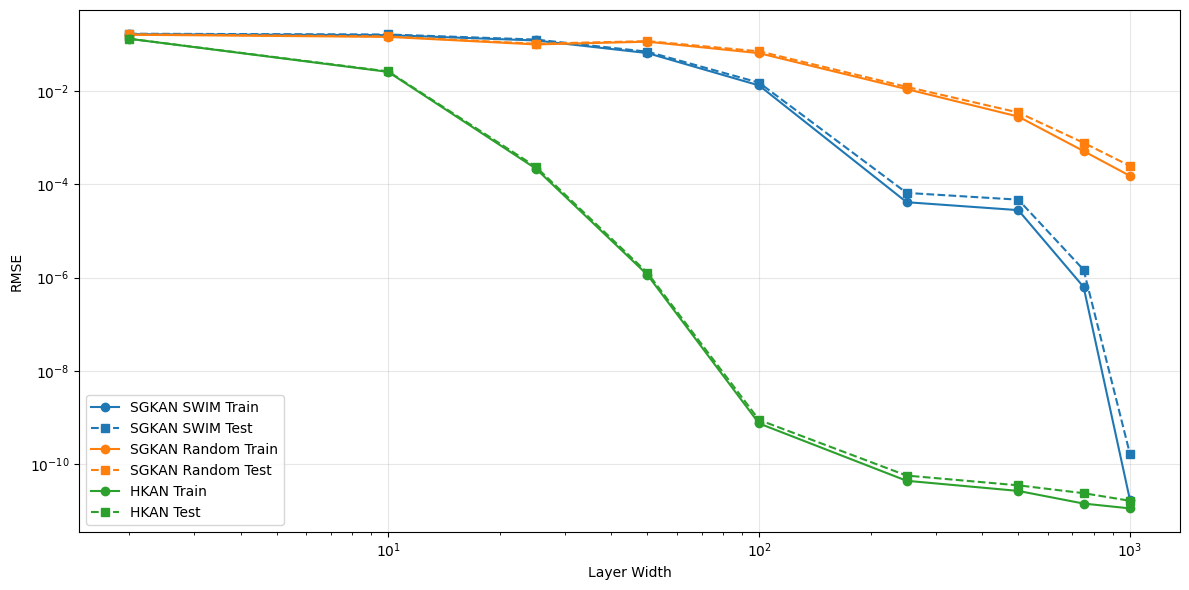

In [19]:
plot_hypothesis_1_results(tf1_hypothesis_1_results_df)

In [20]:
tf1_hypothesis_1_results_df

,Unnamed: 0,layer_width,sgkan_swim_train_rmse,sgkan_swim_test_rmse,sgkan_random_train_rmse,sgkan_random_test_rmse,hkan_train_rmse,hkan_test_rmse
0,0,2,1.6622241134e-01,0.1702255039,0.1619933467,0.1655058884,1.3286104600e-01,1.3303030606e-01
1,1,10,1.5892349659e-01,0.1639006045,0.1457391523,0.1490251091,2.5849179251e-02,2.6468756615e-02
2,2,25,1.2209953546e-01,0.1277152683,0.1003967854,0.1038198899,2.1855769224e-04,2.3885655786e-04
3,3,50,6.5512731335e-02,0.0701368481,0.1148422973,0.1181960046,1.1490466657e-06,1.2690709363e-06
4,4,100,1.3245869591e-02,0.0151921539,0.0652059654,0.0714701304,7.4564740764e-10,8.8788353486e-10
5,5,250,4.1481591726e-05,0.0000656181,0.0110519513,0.0123550449,4.3970661393e-11,5.6898401583e-11
6,6,500,2.8050201600e-05,0.0000470535,0.0028457322,0.0034820677,2.6656996619e-11,3.5125395552e-11
7,7,750,6.3065819595e-07,0.0000014729,0.0005177078,0.0007787780,1.4269753034e-11,2.3828897986e-11
8,8,1000,1.7145528925e-11,0.0000000002,0.0001522128,0.0002490166,1.1250849873e-11,1.6398886949e-11


### Explore Feature importances and Layers

Examine how well each input feature is being captured by the first layer of the best model. This helps us understand which input dimensions are most important and how the model processes the input space.

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1204, 'interval': 755, 'knn_fallback': 41}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 858, 'interval': 137, 'knn_fallback': 5}


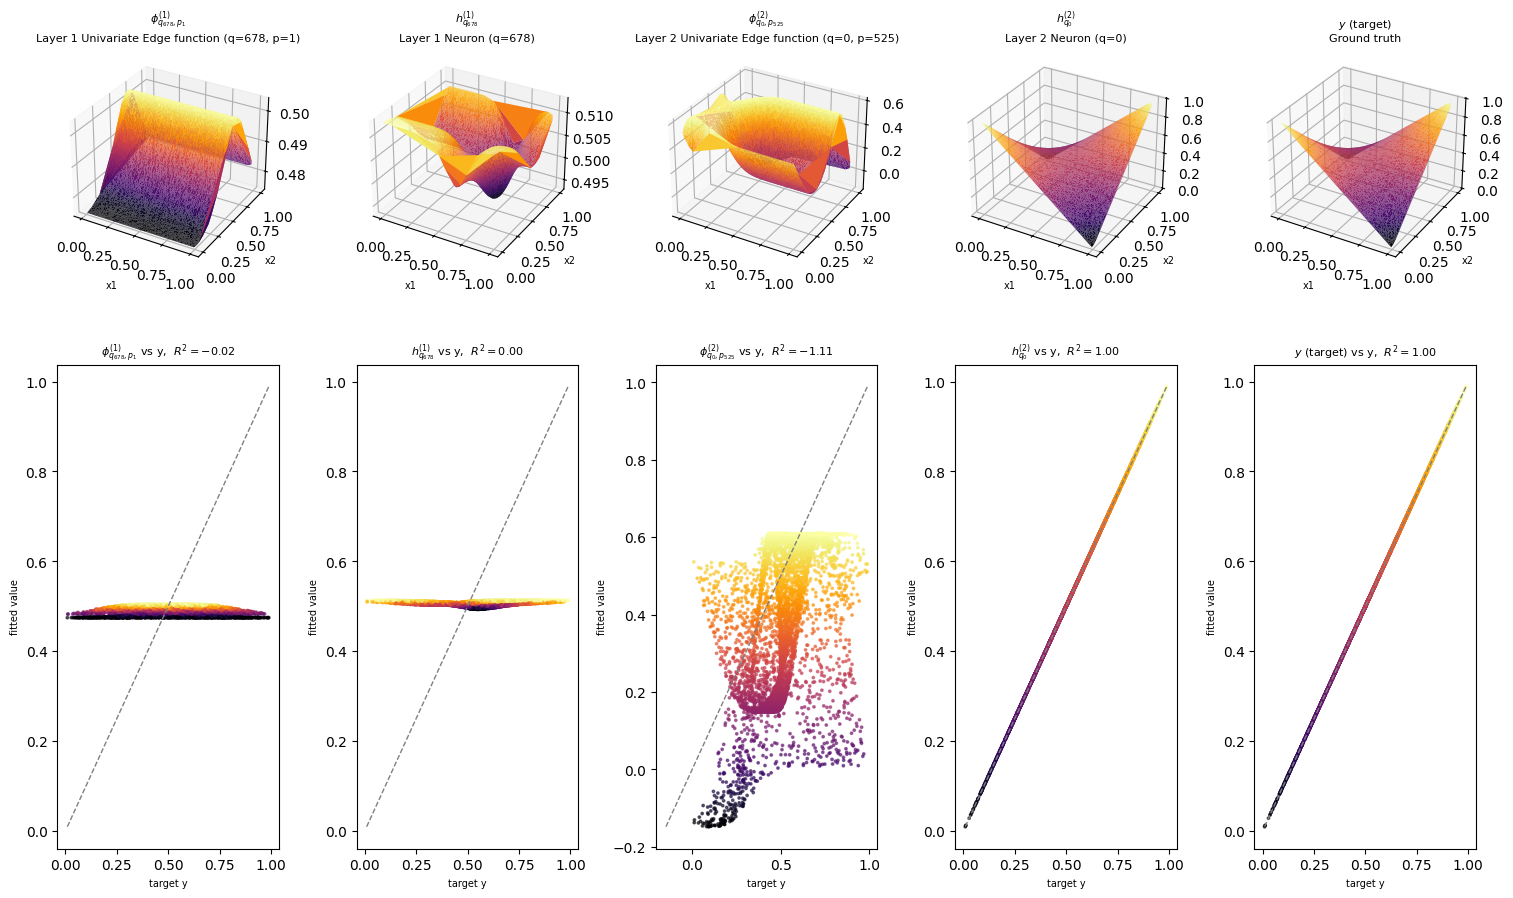

In [21]:
best_tf1_sgkan_stages, best_tf1_sgkan_ytrain_hat, best_tf1_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf1_x_train, tf1_y_train, best_tf1_configs)
visualize.plot_model_stages(tf1_x_train, tf1_y_train, best_tf1_sgkan_stages, block_idx="random")

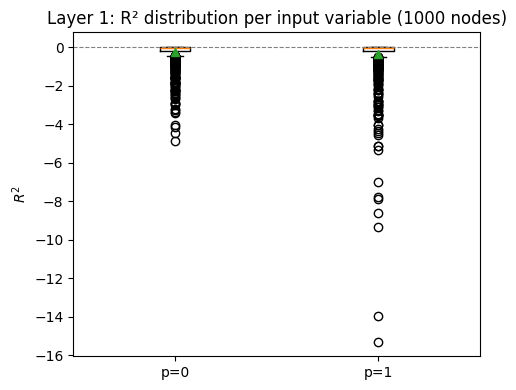

In [22]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf1_sgkan_stages, tf1_y_train)

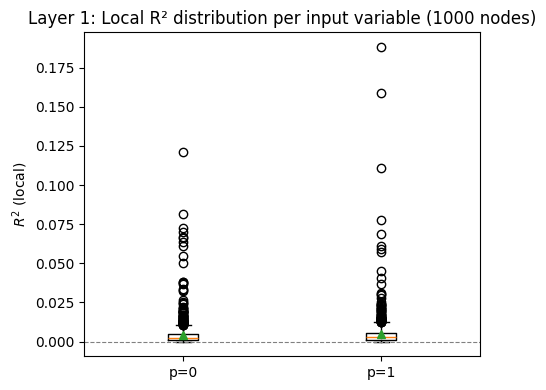

In [23]:
plot_first_layer_local_edge_r2_summary(best_tf1_sgkan_layer_neurons)

## TF2

For TF2, we'll find the best SGKAN configuration through hyperparameter optimization, then run a robustness test with 50 random seeds to compare against our HKAN reproduction, configured with the paper's best reported hyperparameters. We'll also explore how layer width impacts performance and which input features matter most.

### Sanity Check

Sanity check that the model runs without errors. This serves as a basic test before moving to optimization and comparison experiments.

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=500, D_in=2)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 541, 'interval': 449, 'knn_fallback': 10}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=500)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 386, 'interval': 112, 'knn_fallback': 2}
TF2 SGKAN train R2: 0.5748540761535592


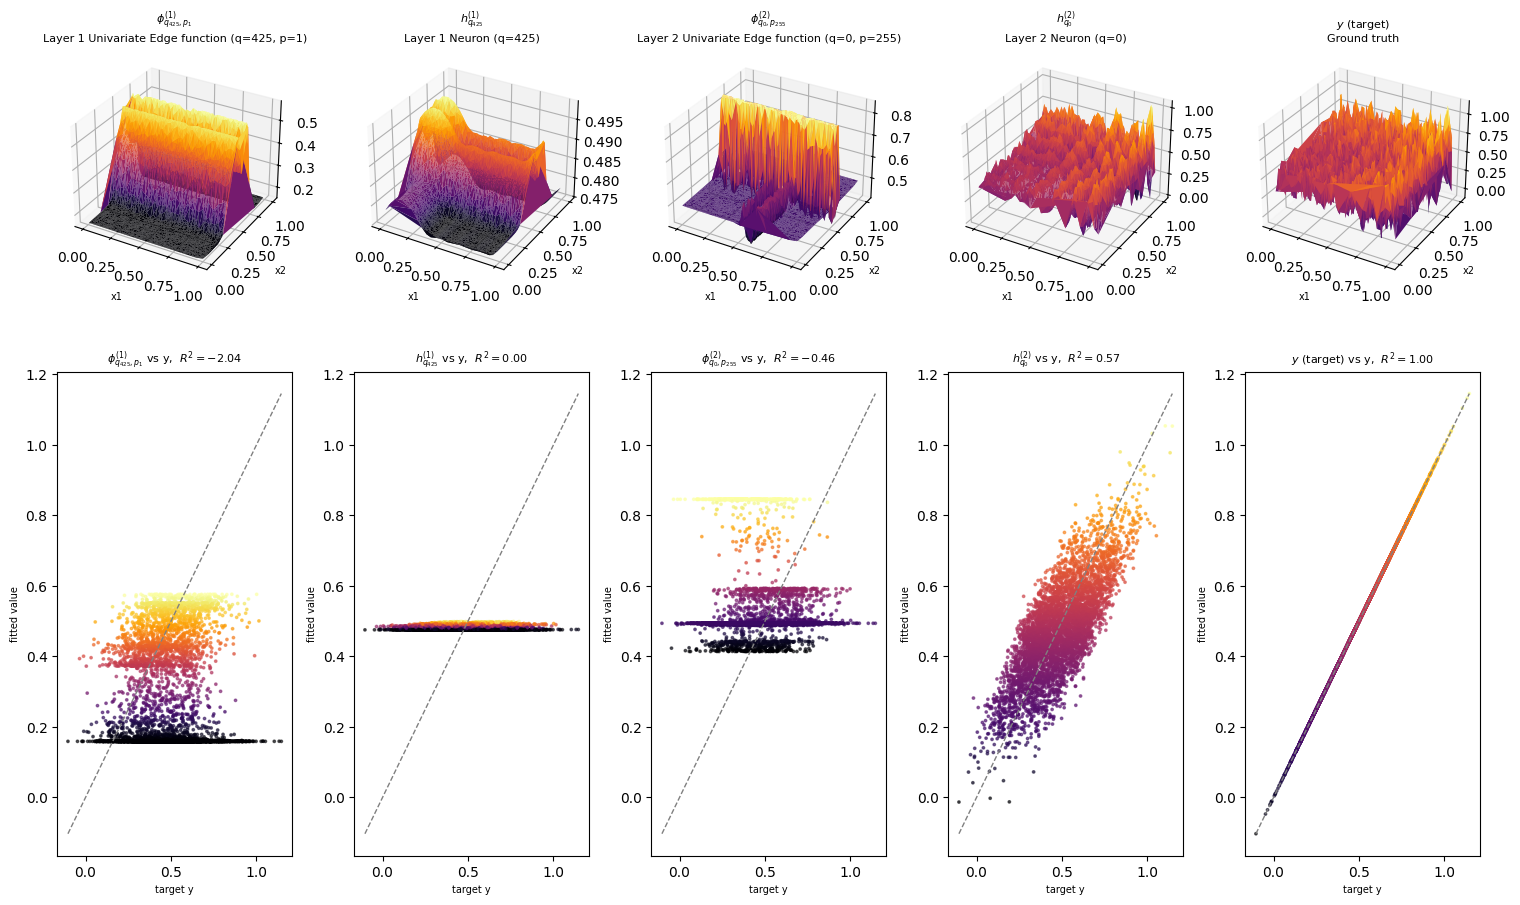

In [24]:
tf2_sgkan_layer_swim_configs = [
    {"layer_width": 500, "num_inducing": 25, "pair_selection_strategy": "swim", "alpha_edge": 0.1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "periodic", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 25, "pair_selection_strategy": "swim", "alpha_edge": 0.1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "periodic", "seed": random_seed, "sigma_scale": 1},
]
# A stage item in stages list consists of (layer_idx, phi[q, p, :] edge function results, layer_output) 
tf2_sgkan_stages, tf2_sgkan_ytrain_hat, tf2_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf2_x_train, tf2_y_train, tf2_sgkan_layer_swim_configs)
print("TF2 SGKAN train R2:", r2_score(tf2_y_train, tf2_sgkan_ytrain_hat))

visualize.plot_model_stages(tf2_x_train, tf2_y_train, tf2_sgkan_stages, block_idx="random", seed=0)

In [25]:
tf2_sgkan_model = sgkan_model.SGKANModel(tf2_sgkan_layer_swim_configs).fit(tf2_x_train, tf2_y_train)

tf2_sgkan_results = em.evaluate(
    tf2_sgkan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)
em.print_results(tf2_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=500, D_in=2)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 541, 'interval': 449, 'knn_fallback': 10}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=500)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 386, 'interval': 112, 'knn_fallback': 2}
[SGKANModel.fit] Total fit duration: 11.4014s
Metric          Train                Test                
-------------------------------------------------------
MAE             9.591235e-02         4.004381e-02        
RMSE            1.131952e-01         5.230537e-02        
-------------------------------------------------------
Inference (s)   3.721818             6.658761            


### Optuna - Parameter Search

Find the best layer configuration for TF2 dataset.

In [26]:
tf2_result = sps.study_optuna_sgkan(
    "tf2", tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test,
    n_trials=375
)

Results found for tf2. Loading from data/tf2_sgkan_optuna_search.csv
Best Validation RMSE:   0.121401919822631
Best Test RMSE:          0.069466691865074
Best layer_width:        250
Best num_inducing:       10
Best alpha_edge:         1.000e+00
Best alpha_neuron:       0.000e+00
Best kernel_type:        rbf

All 375 trials:
     number           value  params_layer_width  params_num_inducing  params_alpha_edge  params_alpha_neuron params_kernel_type        val_rmse     test_rmse
0         0    0.1341706757                1000                   50              0.001                    0             matern    0.1341706757           NaN
1         1    0.1690794742                1000                   25              1.000                    0           periodic    0.1690794742           NaN
2         2    0.1286880126                 500                   50             10.000                    0                rbf    0.1286880126           NaN
3         3    0.1301444605              

In [27]:
# Use best parameter configuration to fit an SGKAN model again
best_tf2_configs = tf2_result["layer_configs"]
best_tf2_configs

[{'layer_width': 250,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

In [28]:
tf2_sgkan_optuna_df = pd.read_csv("data/tf2_sgkan_optuna_search.csv")
tf2_sgkan_optuna_df.sort_values("val_rmse").head(5)

,number,value,datetime_start,datetime_complete,duration,params_alpha_edge,params_alpha_neuron,params_kernel_type,params_layer_width,params_num_inducing,...,fit_duration_sec,kernel_type,user_attrs_layer_width,user_attrs_num_inducing,sigma_scale,val_rmse,system_attrs_grid_id,system_attrs_search_space,state,test_rmse
50,50,0.1214019198,2026-08-06 18:54:32.364016,2026-08-06 18:54:33.499482,1.135466,1.000,0,rbf,250,10,...,1.052490375,rbf,250,10,1,0.1214019198,50,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,0.0694666919
113,113,0.1216280767,2026-08-06 19:07:10.253905,2026-08-06 19:07:11.311886,1.057981,0.100,0,rbf,250,10,...,0.959779833,rbf,250,10,1,0.1216280767,113,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
316,316,0.1219895807,2026-08-06 19:43:01.154879,2026-08-06 19:43:02.466117,1.311238,0.001,0,matern,250,10,...,1.109804250,matern,250,10,1,0.1219895807,316,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
276,276,0.1225866840,2026-08-06 19:34:34.476535,2026-08-06 19:34:44.303424,9.826889,0.100,0,matern,500,50,...,8.990966625,matern,500,50,1,0.1225866840,276,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
41,41,0.1227289119,2026-08-06 18:52:49.025630,2026-08-06 18:52:51.341801,2.316171,10.000,0,rbf,250,25,...,2.151501833,rbf,250,25,1,0.1227289119,41,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN


In [29]:
best_tf2_sgkan_model = sgkan_model.SGKANModel(best_tf2_configs).fit(tf2_x_train, tf2_y_train)

best_tf2_sgkan_results = em.evaluate(
    best_tf2_sgkan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)
em.print_results(best_tf2_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=250, D_in=2)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 281, 'interval': 215, 'knn_fallback': 4}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=250)
[fit_layer] local-window method counts over 250 edges: {'interval': 166, 'interval_capped': 84}
[SGKANModel.fit] Total fit duration: 1.4549s
Metric          Train                Test                
-------------------------------------------------------
MAE             1.067455e-01         5.087396e-02        
RMSE            1.275607e-01         6.946669e-02        
-------------------------------------------------------
Inference (s)   0.357451             0.654250            


In [30]:
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf2_configs = copy.deepcopy(best_tf2_configs)
for i in random_best_tf2_configs:
    i['pair_selection_strategy'] = "random"
random_best_tf2_configs, best_tf2_configs

([{'layer_width': 250,
   'num_inducing': 10,
   'pair_selection_strategy': 'random',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 10,
   'pair_selection_strategy': 'random',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}],
 [{'layer_width': 250,
   'num_inducing': 10,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 10,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}])

In [31]:
random_best_tf2_sgkan_model = sgkan_model.SGKANModel(random_best_tf2_configs).fit(tf2_x_train, tf2_y_train)

random_best_tf2_sgkan_results = em.evaluate(
    random_best_tf2_sgkan_model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test
)
em.print_results(random_best_tf2_sgkan_results)

[fit_layer] pair_selection_strategy = 'random' (layer_width=250, D_in=2)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 306, 'interval': 193, 'knn_fallback': 1}
[fit_layer] pair_selection_strategy = 'random' (layer_width=1, D_in=250)
[fit_layer] local-window method counts over 250 edges: {'interval': 229, 'knn_fallback': 21}
[SGKANModel.fit] Total fit duration: 2.2365s
Metric          Train                Test                
-------------------------------------------------------
MAE             1.098720e-01         6.039654e-02        
RMSE            1.320654e-01         8.338002e-02        
-------------------------------------------------------
Inference (s)   0.433378             0.736626            


### 50 seed results

Run the best SGKAN model 50 times with different random seeds to compute median and IQR of RMSE, matching the methodology from HKAN's paper for fair comparison. This statistical approach accounts for the randomness in pair selection and provides a robust measure of model performance variability.

In [32]:
tf2_50_runs_path = "data/tf2_sgkan_50_run_results.csv"

if os.path.exists(tf2_50_runs_path):
    tf2_50_runs_df = pd.read_csv("data/tf2_sgkan_50_run_results.csv")
else:
    tf2_50_runs = run_sgkan_seed_experiments(tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test, best_tf2_configs, n_runs=50)
    tf2_50_runs_df = create_export_seed_results(tf2_50_runs, "tf2_sgkan_50_run_results")
tf2_50_runs_df.head()

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs
0,0,0.1067454811,0.1275607046,0.364391917,0.0508739642,0.0694666919,1.282503875
1,1,0.1045831408,0.1239307342,0.570958958,0.0425268903,0.0600911949,0.729506000
2,2,0.1001727244,0.1169034136,0.613171667,0.0305358252,0.0407585599,1.079269375
3,3,0.1084668558,0.1309656356,0.557838375,0.0557595407,0.0756283244,0.979005042
4,4,0.1048370478,0.1253916277,0.333308792,0.0489197713,0.0646528312,0.649013708


In [33]:
summarize_metrics(tf2_50_runs_df, "SGKAN SWIM")

{'model': 'SGKAN SWIM',
 'train_rmse_median': 0.11875063275247025,
 'train_rmse_iqr': 0.010023946168560713,
 'test_rmse_median': 0.04967918844018455,
 'test_rmse_iqr': 0.025488867369778387}

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

Compare how increasing the first layer width affects performance across SGKAN (SWIM), SGKAN (random), and HKAN. All other parameters stay fixed to isolate the width effect. The goal is to understand whether wider layers consistently improve predictions and if this trend differs between the algorithms.

In [34]:
# Best TF2 HKAN configuration from the paper
tf2_hkan_layer_configs = [
    dict(layer=0, n_vars_out=48, n_basis=17, centers="random", basis_fn=Tanh(s=22), expanding_base_regressor=Ridge(alpha=0.1)),
    dict(layer=1, n_vars_out=11, n_basis=21, centers="random_data_points", basis_fn=Softplus(s=18), expanding_base_regressor=Ridge(alpha=1)),
    dict(layer=2, n_vars_out=1, n_basis=1, centers="equally_spaced", basis_fn=Identity(), expanding_base_regressor=None),
]

In [35]:
tf2_hypothesis_1_path = "data/tf2_hypothesis_1_results_df.csv"

if os.path.exists(tf2_hypothesis_1_path):
    tf2_hypothesis_1_results_df = pd.read_csv("data/tf2_hypothesis_1_results_df.csv")
else:
    # Define layer widths
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    # Results storage
    results = {
        'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
    }

    # SGKAN with SWIM
    print("Testing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf2_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf2_x_train, tf2_y_train)
        eval_results = em.evaluate(model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
        results['sgkan_swim']['widths'].append(width)
        results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # SGKAN with random pair selection
    print("\nTesting SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf2_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf2_x_train, tf2_y_train)
        eval_results = em.evaluate(model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
        results['sgkan_random']['widths'].append(width)
        results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # HKAN with best config
    print("\nTesting HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf2_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf2_x_train, tf2_y_train)
        eval_results = em.evaluate(model, tf2_x_train, tf2_y_train, tf2_x_test, tf2_y_test)
        results['hkan']['widths'].append(width)
        results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
        results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # Display results
    tf2_hypothesis_1_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
        'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
        'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
        'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
        'hkan_train_rmse': results['hkan']['train_rmse'],
        'hkan_test_rmse': results['hkan']['test_rmse']
    })
    tf2_hypothesis_1_results_df.to_csv("data/tf2_hypothesis_1_results_df.csv")

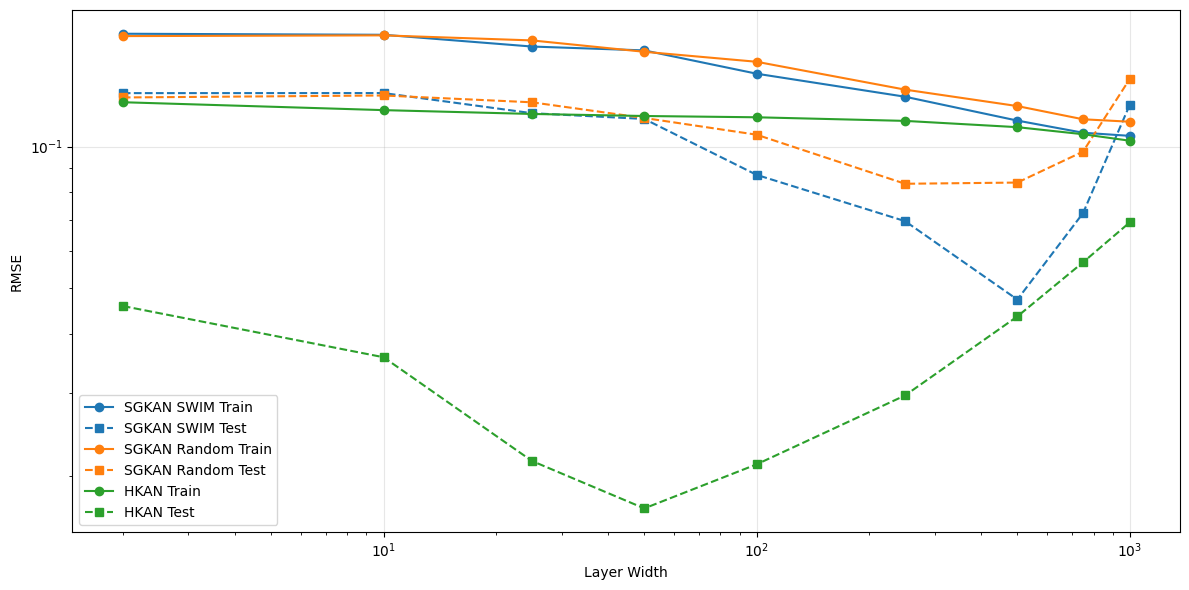

In [36]:
plot_hypothesis_1_results(tf2_hypothesis_1_results_df)

In [37]:
tf2_hypothesis_1_results_df

,Unnamed: 0,layer_width,sgkan_swim_train_rmse,sgkan_swim_test_rmse,sgkan_random_train_rmse,sgkan_random_test_rmse,hkan_train_rmse,hkan_test_rmse
0,0,2,0.1735185434,0.1298207615,0.1715255581,0.1271046572,0.1241776520,0.0458912162
1,1,10,0.1726360656,0.1298613835,0.1721432570,0.1283411254,0.1194761976,0.0357336046
2,2,25,0.1629959797,0.1176966456,0.1679469443,0.1241286892,0.1172616217,0.0215248571
3,3,50,0.1599413292,0.1144316878,0.1588630221,0.1149786635,0.1160973718,0.0170770008
4,4,100,0.1427467974,0.0870922740,0.1513077167,0.1059635830,0.1153739197,0.0211762121
5,5,250,0.1275607046,0.0694666919,0.1320654275,0.0833800243,0.1133607505,0.0296479180
6,6,500,0.1135196432,0.0473609853,0.1218654462,0.0838721966,0.1099367299,0.0436140270
7,7,750,0.1069899347,0.0722582727,0.1142505903,0.0975679478,0.1062068916,0.0568130989
8,8,1000,0.1053740007,0.1224873999,0.1129077488,0.1390335385,0.1028984409,0.0690189410


### Explore Feature importances and Layers

Examine how well each input feature is being captured by the first layer of the best model. This helps us understand which input dimensions are most important and how the model processes the input space.

In [38]:
best_tf2_configs

[{'layer_width': 250,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=250, D_in=2)
[fit_layer] local-window method counts over 500 edges: {'interval_capped': 281, 'interval': 215, 'knn_fallback': 4}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=250)
[fit_layer] local-window method counts over 250 edges: {'interval': 166, 'interval_capped': 84}


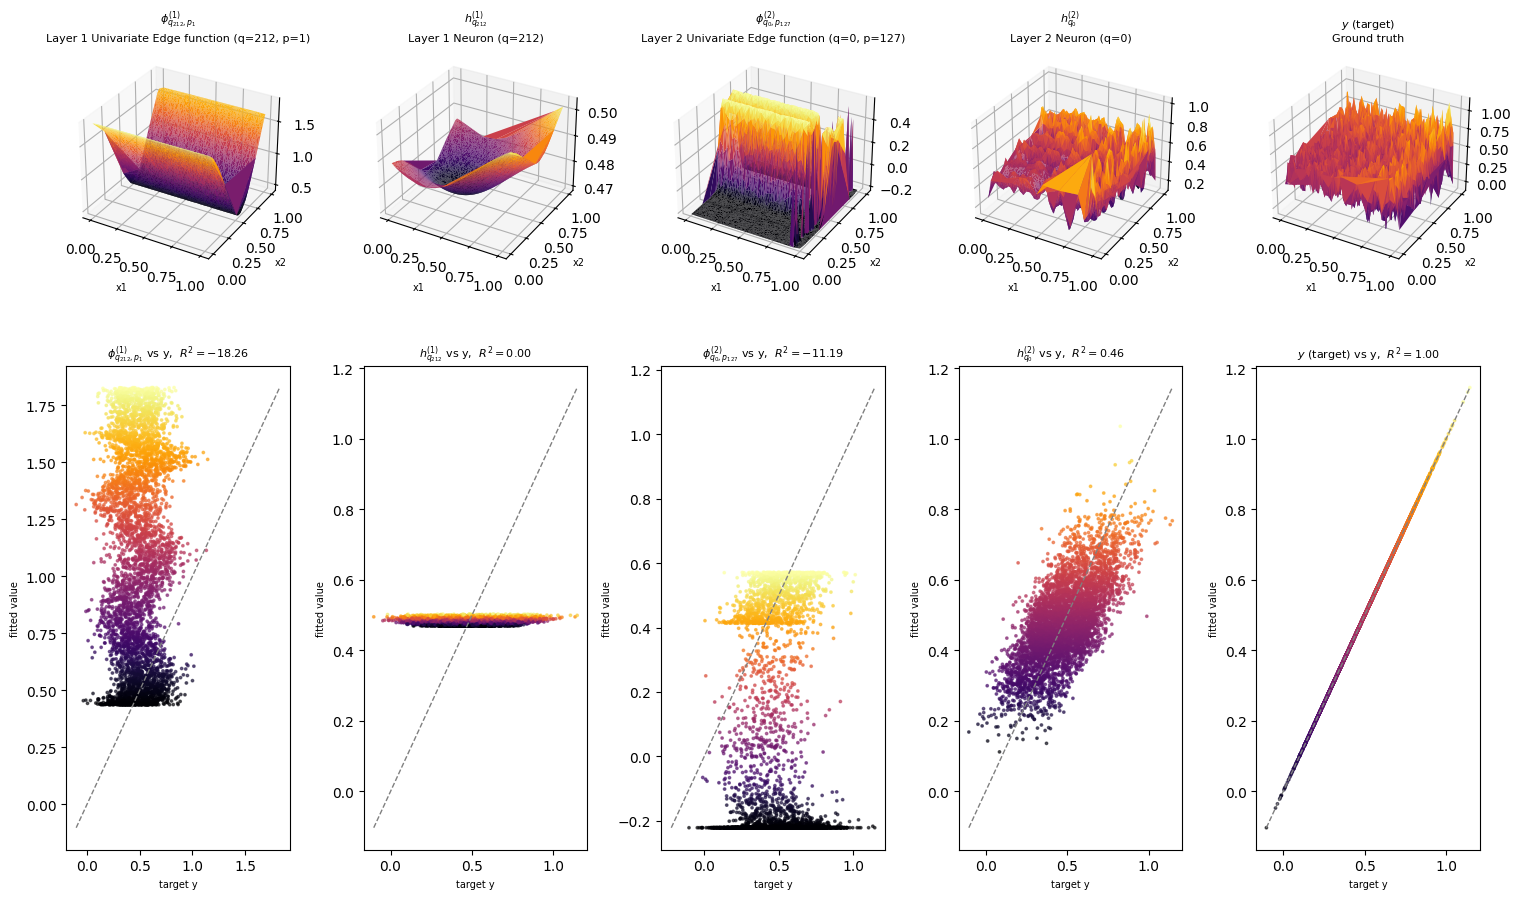

In [39]:
best_tf2_sgkan_stages, best_tf2_sgkan_ytrain_hat, best_tf2_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf2_x_train, tf2_y_train, best_tf2_configs)
visualize.plot_model_stages(tf2_x_train, tf2_y_train, best_tf2_sgkan_stages, block_idx="random", seed=0)

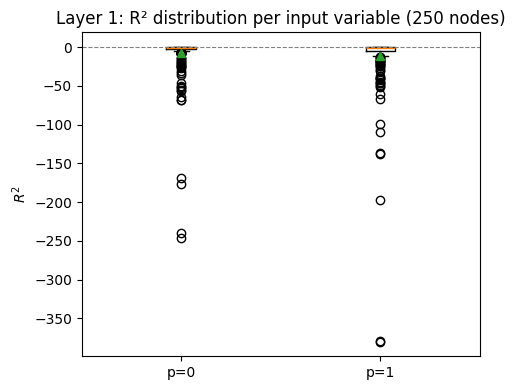

In [40]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf2_sgkan_stages, tf2_y_train)

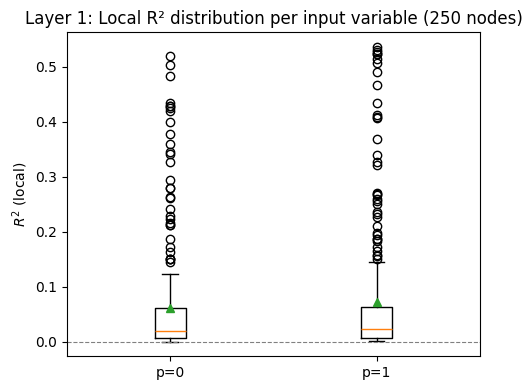

In [41]:
plot_first_layer_local_edge_r2_summary(best_tf2_sgkan_layer_neurons)

## TF3

For TF3, we'll find the best SGKAN configuration through hyperparameter optimization, then run a robustness test with 50 random seeds to compare against our HKAN reproduction, configured with the paper's best reported hyperparameters. We'll also explore how layer width impacts performance and which input features matter most.

### Sanity Check

Sanity check that the model runs without errors. This serves as a basic test before moving to optimization and comparison experiments.

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=100, D_in=2)
[fit_layer] local-window method counts over 200 edges: {'interval': 85, 'interval_capped': 106, 'knn_fallback': 9}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=100)
[fit_layer] local-window method counts over 100 edges: {'interval': 44, 'interval_capped': 54, 'knn_fallback': 2}
TF3 SGKAN train R2: 0.802405901240184


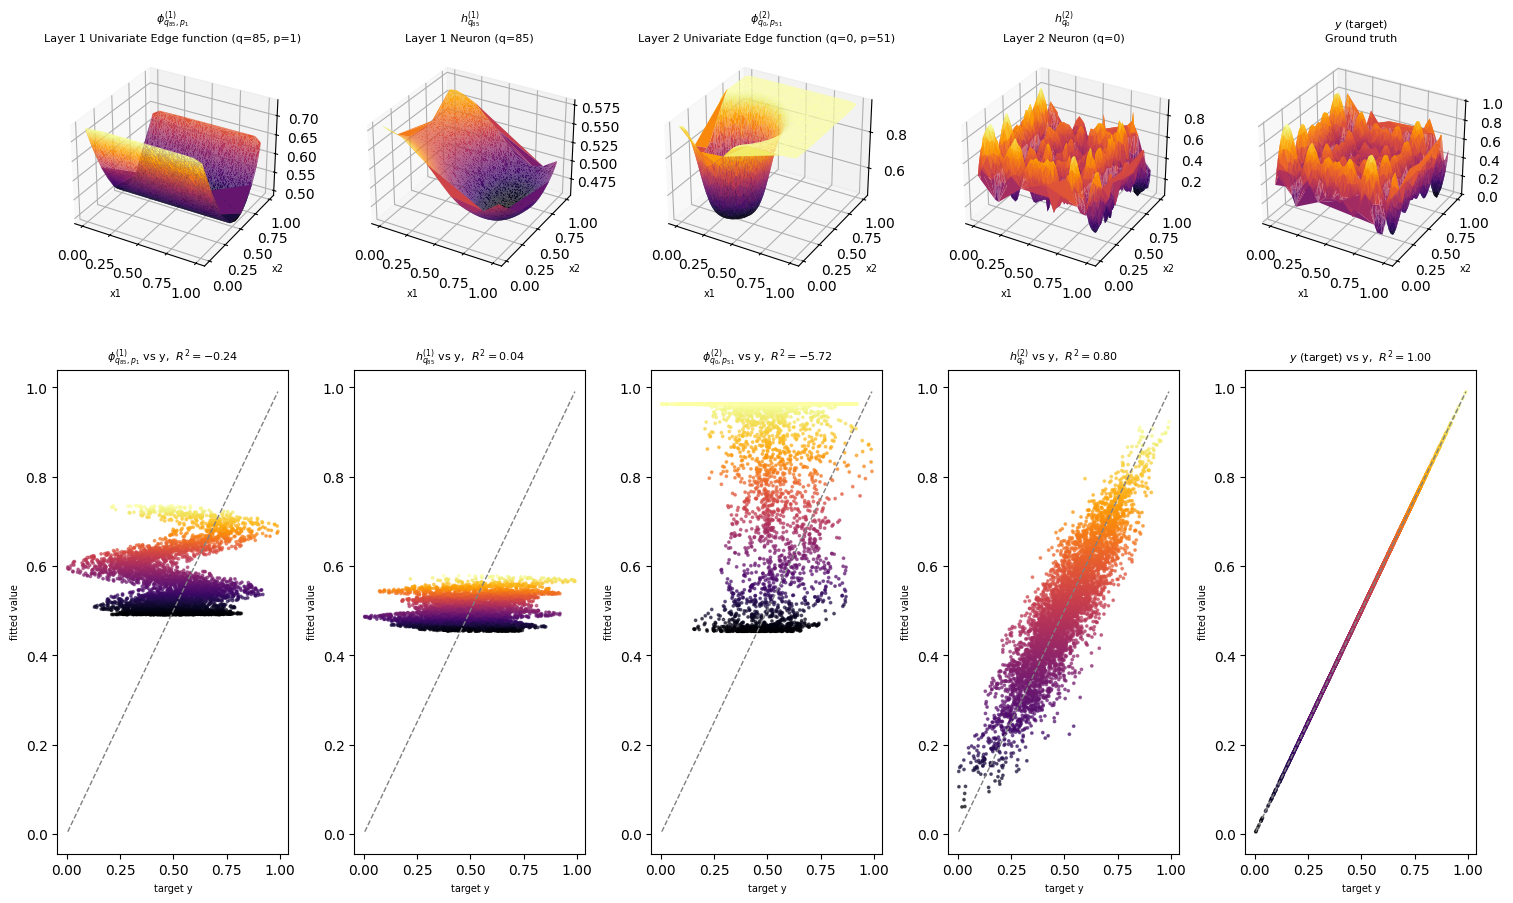

In [42]:
tf3_sgkan_layer_swim_configs = [
    {"layer_width": 100, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
]
# A stage item in stages list consists of (layer_idx, phi[q, p, :] edge function results, layer_output) 
tf3_sgkan_stages, tf3_sgkan_ytrain_hat, tf3_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf3_x_train, tf3_y_train, tf3_sgkan_layer_swim_configs)
print("TF3 SGKAN train R2:", r2_score(tf3_y_train, tf3_sgkan_ytrain_hat))

visualize.plot_model_stages(tf3_x_train, tf3_y_train, tf3_sgkan_stages, block_idx="random", seed=0)

In [43]:
tf3_sgkan_model = sgkan_model.SGKANModel(tf3_sgkan_layer_swim_configs).fit(tf3_x_train, tf3_y_train)

tf3_sgkan_results = em.evaluate(
    tf3_sgkan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)
em.print_results(tf3_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=100, D_in=2)
[fit_layer] local-window method counts over 200 edges: {'interval': 85, 'interval_capped': 106, 'knn_fallback': 9}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=100)
[fit_layer] local-window method counts over 100 edges: {'interval': 44, 'interval_capped': 54, 'knn_fallback': 2}
[SGKANModel.fit] Total fit duration: 2.9511s
Metric          Train                Test                
-------------------------------------------------------
MAE             5.646379e-02         5.958137e-02        
RMSE            7.157783e-02         7.586610e-02        
-------------------------------------------------------
Inference (s)   0.939413             1.911714            


### Optuna - Parameter Search

Find the best layer configuration for TF3 dataset.

In [44]:
tf3_result = sps.study_optuna_sgkan(
    "tf3", tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test,
    n_trials=375
)

Results found for tf3. Loading from data/tf3_sgkan_optuna_search.csv
Best Validation RMSE:   0.001775376543405
Best Test RMSE:          0.001930666056172
Best layer_width:        1000
Best num_inducing:       10
Best alpha_edge:         1.000e+00
Best alpha_neuron:       0.000e+00
Best kernel_type:        matern

All 375 trials:
     number         value  params_layer_width  params_num_inducing  params_alpha_edge  params_alpha_neuron params_kernel_type      val_rmse     test_rmse
0         0  0.0022323076                1000                   50              0.001                    0             matern  0.0022323076           NaN
1         1  0.0250078299                1000                   25              1.000                    0           periodic  0.0250078299           NaN
2         2  0.0053409934                 500                   50             10.000                    0                rbf  0.0053409934           NaN
3         3  0.0260327840                 500        

In [45]:
# Use best parameter configuration to fit an SGKAN model again
best_tf3_configs = tf3_result["layer_configs"]
best_tf3_configs

[{'layer_width': 1000,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'matern',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'matern',
  'seed': 0,
  'sigma_scale': 1}]

In [46]:
tf3_sgkan_optuna_df = pd.read_csv("data/tf3_sgkan_optuna_search.csv")
tf3_sgkan_optuna_df.sort_values("val_rmse").head(5)

,number,value,datetime_start,datetime_complete,duration,params_alpha_edge,params_alpha_neuron,params_kernel_type,params_layer_width,params_num_inducing,...,fit_duration_sec,kernel_type,user_attrs_layer_width,user_attrs_num_inducing,sigma_scale,val_rmse,system_attrs_grid_id,system_attrs_search_space,state,test_rmse
67,67,0.0017753765,2026-08-06 20:23:20.566744,2026-08-06 20:23:26.234101,5.667357,1.000,0,matern,1000,10,...,5.355064542,matern,1000,10,1,0.0017753765,67,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,0.0019306661
249,249,0.0018877609,2026-08-06 20:55:24.536475,2026-08-06 20:55:35.458627,10.922152,10.000,0,matern,1000,25,...,10.091062208,matern,1000,25,1,0.0018877609,249,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
334,334,0.0019053303,2026-08-06 21:10:27.816179,2026-08-06 21:10:49.045305,21.229126,10.000,0,matern,1000,50,...,19.464694583,matern,1000,50,1,0.0019053303,334,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
233,233,0.0019149387,2026-08-06 20:52:48.526262,2026-08-06 20:53:21.355434,32.829172,10.000,0,matern,1000,75,...,30.349246417,matern,1000,75,1,0.0019149387,233,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
304,304,0.0019795121,2026-08-06 21:06:13.817630,2026-08-06 21:06:24.470728,10.653098,0.001,0,matern,1000,25,...,9.758293000,matern,1000,25,1,0.0019795121,304,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN


In [47]:
best_tf3_sgkan_model = sgkan_model.SGKANModel(best_tf3_configs).fit(tf3_x_train, tf3_y_train)

best_tf3_sgkan_results = em.evaluate(
    best_tf3_sgkan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)
em.print_results(best_tf3_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval': 934, 'interval_capped': 1063, 'knn_fallback': 3}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 782, 'interval': 216, 'knn_fallback': 2}
[SGKANModel.fit] Total fit duration: 6.2294s
Metric          Train                Test                
-------------------------------------------------------
MAE             8.276107e-04         1.145522e-03        
RMSE            1.273151e-03         1.930666e-03        
-------------------------------------------------------
Inference (s)   2.299470             3.782685            


In [48]:
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf3_configs = copy.deepcopy(best_tf3_configs)
for i in random_best_tf3_configs:
    i['pair_selection_strategy'] = "random"
random_best_tf3_configs, best_tf3_configs

([{'layer_width': 1000,
   'num_inducing': 10,
   'pair_selection_strategy': 'random',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'matern',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 10,
   'pair_selection_strategy': 'random',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'matern',
   'seed': 0,
   'sigma_scale': 1}],
 [{'layer_width': 1000,
   'num_inducing': 10,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'matern',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 10,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'matern',
   'seed': 0,
   'sigma_scale': 1}])

In [49]:
random_best_tf3_sgkan_model = sgkan_model.SGKANModel(random_best_tf3_configs).fit(tf3_x_train, tf3_y_train)

random_best_tf3_sgkan_results = em.evaluate(
    random_best_tf3_sgkan_model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test
)
em.print_results(random_best_tf3_sgkan_results)

[fit_layer] pair_selection_strategy = 'random' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1293, 'interval': 699, 'knn_fallback': 8}
[fit_layer] pair_selection_strategy = 'random' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval': 241, 'interval_capped': 756, 'knn_fallback': 3}
[SGKANModel.fit] Total fit duration: 6.7903s
Metric          Train                Test                
-------------------------------------------------------
MAE             9.423248e-04         1.326763e-03        
RMSE            1.383051e-03         2.151302e-03        
-------------------------------------------------------
Inference (s)   1.910566             4.054571            


### 50 seed results

Run the best SGKAN model 50 times with different random seeds to compute median and IQR of RMSE, matching the methodology from HKAN's paper for fair comparison. This statistical approach accounts for the randomness in pair selection and provides a robust measure of model performance variability.

In [50]:
tf3_50_runs_path = "data/tf3_sgkan_50_run_results.csv"

if os.path.exists(tf3_50_runs_path):
    tf3_50_runs_df = pd.read_csv("data/tf3_sgkan_50_run_results.csv") 
else:
    tf3_50_runs = run_sgkan_seed_experiments(tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test, best_tf3_configs, n_runs=50)
    tf3_50_runs_df = create_export_seed_results(tf3_50_runs, "tf3_sgkan_50_run_results")

tf3_50_runs_df.head()

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs
0,0,0.0008276107,0.0012731508,2.556960208,0.0011455222,0.0019306661,4.416438125
1,1,0.0007600679,0.0011716224,2.653202958,0.0010382195,0.0017159208,5.625016834
2,2,0.0006876672,0.0010050366,1.918331833,0.0009483529,0.0015937336,3.904498167
3,3,0.0011159125,0.0016390068,1.890867875,0.0015551112,0.0025344626,3.510150250
4,4,0.0008622185,0.0012821773,1.864316083,0.0011731901,0.0018590527,3.722873500


In [51]:
summarize_metrics(tf3_50_runs_df, "SGKAN SWIM")

{'model': 'SGKAN SWIM',
 'train_rmse_median': 0.001503473604451,
 'train_rmse_iqr': 0.000466252771429,
 'test_rmse_median': 0.00219818099358665,
 'test_rmse_iqr': 0.00045187259095469997}

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

Compare how increasing the first layer width affects performance across SGKAN (SWIM), SGKAN (random), and HKAN. All other parameters stay fixed to isolate the width effect. The goal is to understand whether wider layers consistently improve predictions and if this trend differs between the algorithms.

In [52]:
# Best TF3 HKAN configuration from the paper
tf3_hkan_layer_configs = [
    dict(layer=0, n_vars_out=924, n_basis=39, centers="random", basis_fn=Tanh(s=50), expanding_base_regressor=Ridge(alpha=0.001)),
    dict(layer=1, n_vars_out=1, n_basis=1, centers="equally_spaced", basis_fn=Identity(), expanding_base_regressor=None),
]

In [53]:
tf3_hypothesis_1_path = "data/tf3_hypothesis_1_results_df.csv"

if os.path.exists(tf3_hypothesis_1_path):
    tf3_hypothesis_1_results_df = pd.read_csv("data/tf3_hypothesis_1_results_df.csv")
else:
    # Define layer widths
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    # Results storage
    results = {
        'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
    }

    # SGKAN with SWIM
    print("Testing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf3_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf3_x_train, tf3_y_train)
        eval_results = em.evaluate(model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
        results['sgkan_swim']['widths'].append(width)
        results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # SGKAN with random pair selection
    print("\nTesting SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf3_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf3_x_train, tf3_y_train)
        eval_results = em.evaluate(model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
        results['sgkan_random']['widths'].append(width)
        results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # HKAN with best config
    print("\nTesting HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf3_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf3_x_train, tf3_y_train)
        eval_results = em.evaluate(model, tf3_x_train, tf3_y_train, tf3_x_test, tf3_y_test)
        results['hkan']['widths'].append(width)
        results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
        results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # Display results
    tf3_hypothesis_1_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
        'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
        'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
        'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
        'hkan_train_rmse': results['hkan']['train_rmse'],
        'hkan_test_rmse': results['hkan']['test_rmse']
    })
    tf3_hypothesis_1_results_df.to_csv("data/tf3_hypothesis_1_results_df.csv")

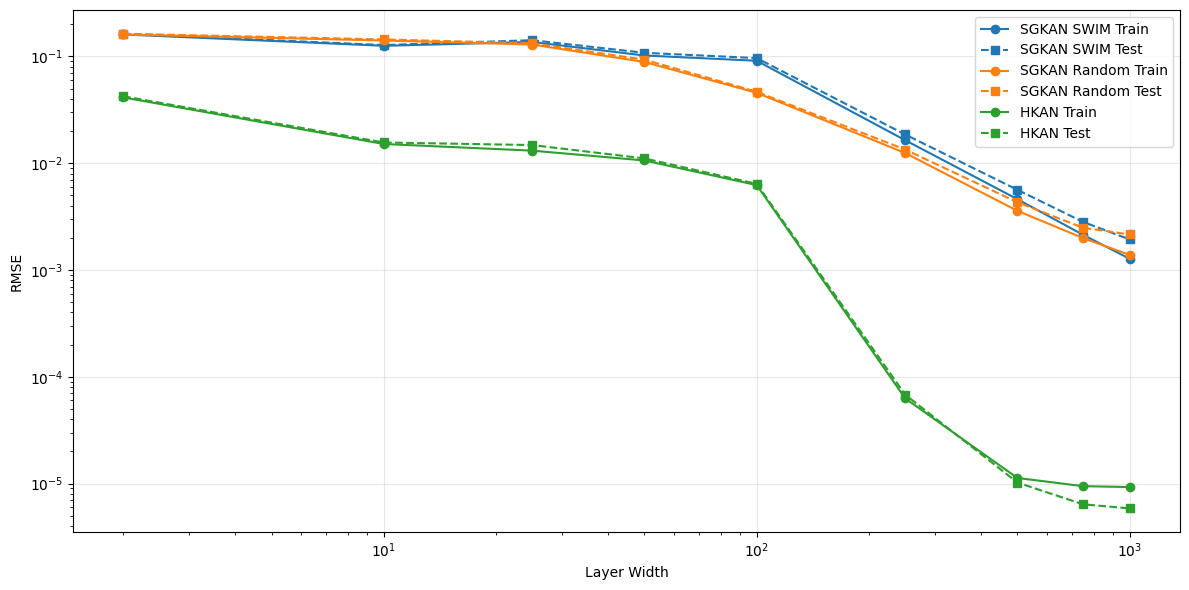

In [54]:
plot_hypothesis_1_results(tf3_hypothesis_1_results_df)

In [55]:
tf3_hypothesis_1_results_df

,Unnamed: 0,layer_width,sgkan_swim_train_rmse,sgkan_swim_test_rmse,sgkan_random_train_rmse,sgkan_random_test_rmse,hkan_train_rmse,hkan_test_rmse
0,0,2,0.1606093891,0.1630949723,0.1605158602,0.1631405447,0.0413471783,0.0423645453
1,1,10,0.1257823704,0.1277947818,0.1410482034,0.1442872287,0.0151379485,0.0156420439
2,2,25,0.1365575334,0.1419306667,0.1292651970,0.1328316965,0.0131144791,0.0147889389
3,3,50,0.1020239614,0.1081215188,0.0887024583,0.0932086263,0.0106056831,0.0110887387
4,4,100,0.0910960646,0.0964419545,0.0456342449,0.0466607254,0.0062389279,0.0064022231
5,5,250,0.0164288195,0.0185831746,0.0124639906,0.0134276973,0.0000628219,0.0000680397
6,6,500,0.0046018345,0.0056317524,0.0035814999,0.0043074089,0.0000112750,0.0000102111
7,7,750,0.0021343556,0.0028185804,0.0019904315,0.0024859061,0.0000094502,0.0000063879
8,8,1000,0.0012731508,0.0019306661,0.0013830508,0.0021513025,0.0000092675,0.0000058519


### Explore Feature importances and Layers

Examine how well each input feature is being captured by the first layer of the best model. This helps us understand which input dimensions are most important and how the model processes the input space.

In [56]:
best_tf3_configs

[{'layer_width': 1000,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'matern',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 10,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'matern',
  'seed': 0,
  'sigma_scale': 1}]

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval': 934, 'interval_capped': 1063, 'knn_fallback': 3}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 782, 'interval': 216, 'knn_fallback': 2}


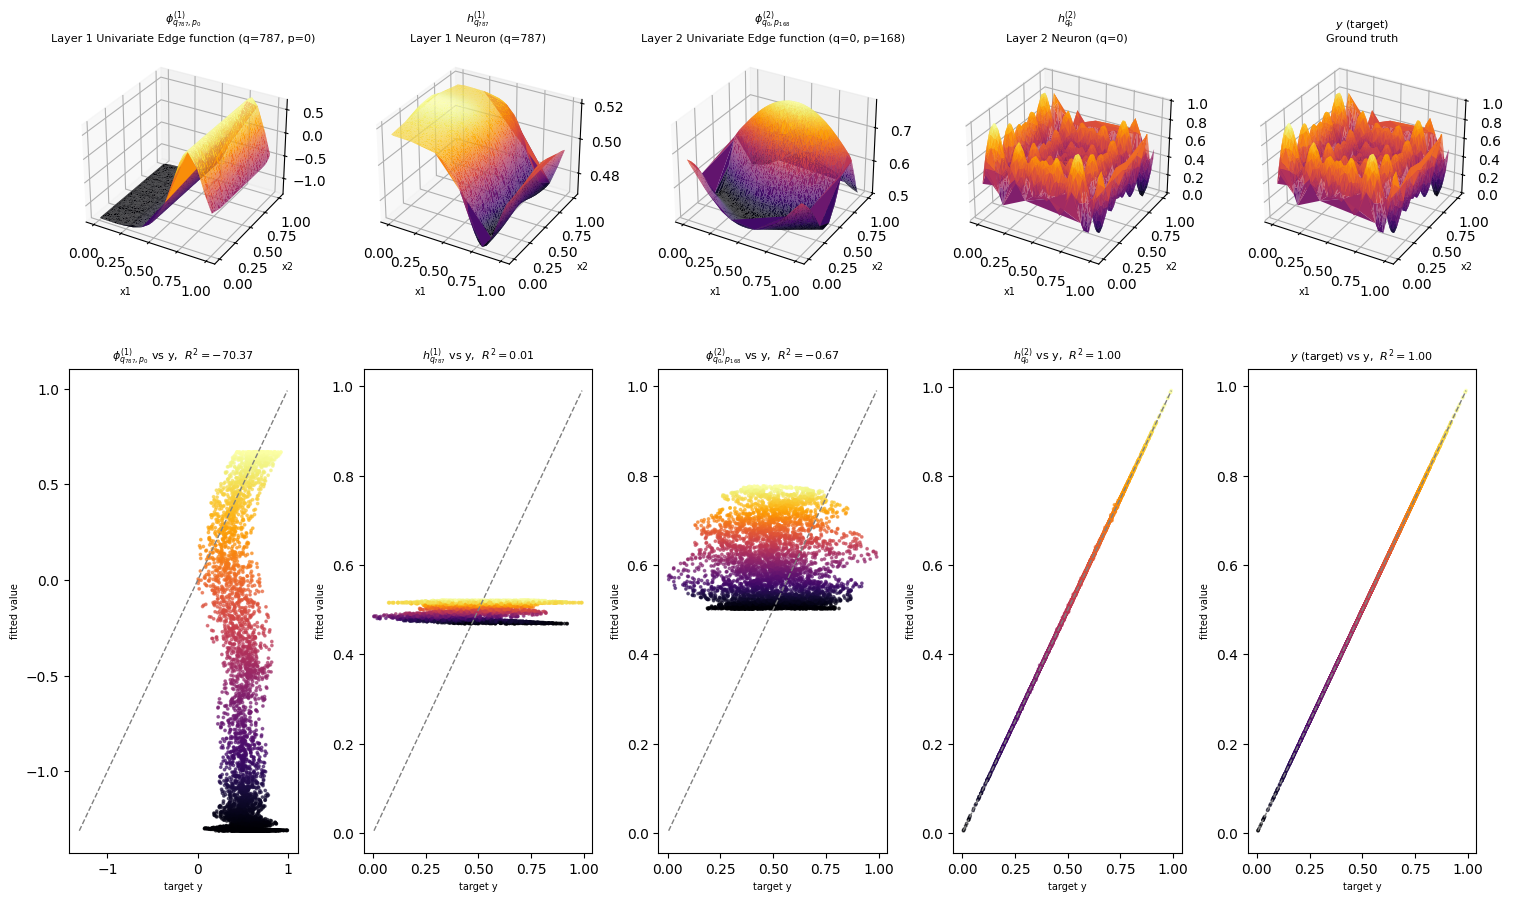

In [57]:
best_tf3_sgkan_stages, best_tf3_sgkan_ytrain_hat, best_tf3_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf3_x_train, tf3_y_train, best_tf3_configs)
visualize.plot_model_stages(tf3_x_train, tf3_y_train, best_tf3_sgkan_stages, block_idx="random")

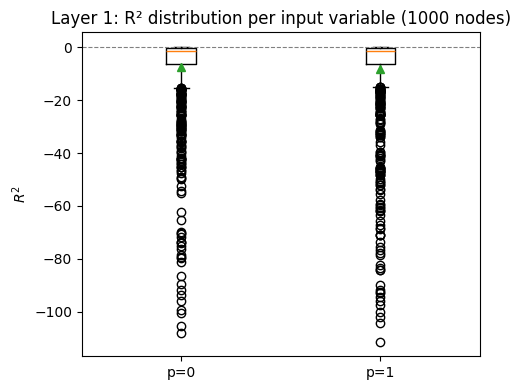

In [58]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf3_sgkan_stages, tf3_y_train)

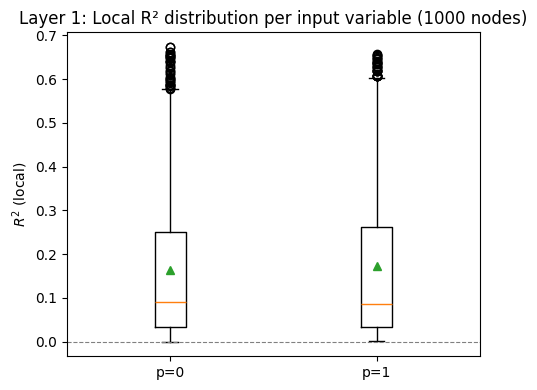

In [59]:
plot_first_layer_local_edge_r2_summary(best_tf3_sgkan_layer_neurons)

## TF4

For TF4, we'll find the best SGKAN configuration through hyperparameter optimization, then run a robustness test with 50 random seeds to compare against our HKAN reproduction, configured with the paper's best reported hyperparameters. We'll also explore how layer width impacts performance and which input features matter most.

### Sanity Check

Sanity check that the model runs without errors. This serves as a basic test before moving to optimization and comparison experiments.

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=10)
[fit_layer] local-window method counts over 10000 edges: {'interval_capped': 5243, 'interval': 4659, 'knn_fallback': 98}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 606, 'interval': 384, 'knn_fallback': 10}
TF4 SGKAN train R2: 0.3016312212032336


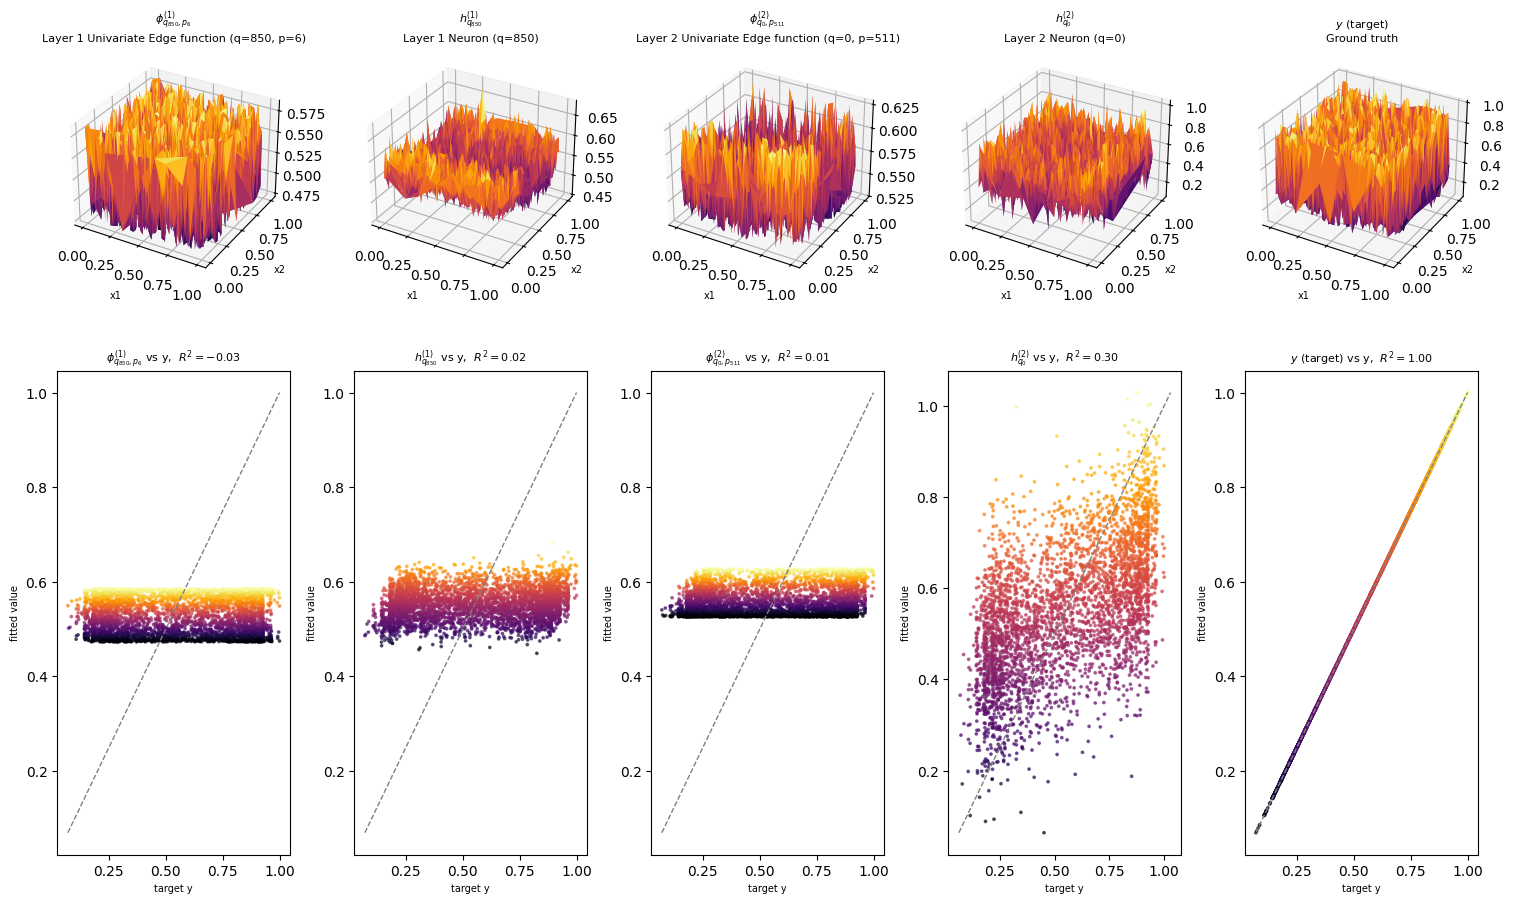

In [60]:
tf4_sgkan_layer_swim_configs = [
    {"layer_width": 1000, "num_inducing": 20, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 20, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
]
# A stage item in stages list consists of (layer_idx, phi[q, p, :] edge function results, layer_output) 
tf4_sgkan_stages, tf4_sgkan_ytrain_hat, tf4_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf4_x_train, tf4_y_train, tf4_sgkan_layer_swim_configs)
print("TF4 SGKAN train R2:", r2_score(tf4_y_train, tf4_sgkan_ytrain_hat))

visualize.plot_model_stages(tf4_x_train, tf4_y_train, tf4_sgkan_stages, block_idx="random", seed=0)

In [61]:
tf4_sgkan_model = sgkan_model.SGKANModel(tf4_sgkan_layer_swim_configs).fit(tf4_x_train, tf4_y_train)

tf4_sgkan_results = em.evaluate(
    tf4_sgkan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)
em.print_results(tf4_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=10)
[fit_layer] local-window method counts over 10000 edges: {'interval_capped': 5243, 'interval': 4659, 'knn_fallback': 98}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 606, 'interval': 384, 'knn_fallback': 10}
[SGKANModel.fit] Total fit duration: 25.4881s
Metric          Train                Test                
-------------------------------------------------------
MAE             1.846019e-01         2.529322e-01        
RMSE            2.199359e-01         3.004744e-01        
-------------------------------------------------------
Inference (s)   6.166383             2.254440            


### Optuna - Parameter Search

Find the best layer configuration for TF4 dataset.

In [62]:
import importlib
importlib.reload(sps)
sps.NUM_INDUCING_OPTIONS, sps.LAYER_WIDTH_OPTIONS

([50, 75, 100], [750, 1000])

In [63]:
tf4_result = sps.study_optuna_sgkan(
    "tf4", tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test,
    n_trials=6
)

Results found for tf4. Loading from data/tf4_sgkan_optuna_search.csv
Best Validation RMSE:   0.313910293974123
Best Test RMSE:          0.284878611883319
Best layer_width:        750
Best num_inducing:       100
Best alpha_edge:         1.000e+00
Best alpha_neuron:       0.000e+00
Best kernel_type:        rbf

All 6 trials:
   number         value  params_layer_width  params_num_inducing  params_alpha_edge  params_alpha_neuron params_kernel_type      val_rmse     test_rmse
0       0  0.3271305006                1000                  100                  1                    0                rbf  0.3271305006           NaN
1       1  0.3139102940                 750                  100                  1                    0                rbf  0.3139102940  0.2848786119
2       2  0.3206821765                 750                   75                  1                    0                rbf  0.3206821765           NaN
3       3  0.3316769512                1000                   50  

In [64]:
# Use best parameter configuration to fit an SGKAN model again
best_tf4_configs = tf4_result["layer_configs"]
best_tf4_configs

[{'layer_width': 750,
  'num_inducing': 100,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 100,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

In [65]:
tf4_sgkan_optuna_df = pd.read_csv("data/tf4_sgkan_optuna_search.csv")
tf4_sgkan_optuna_df.sort_values("val_rmse").head(5)

,number,value,datetime_start,datetime_complete,duration,params_alpha_edge,params_alpha_neuron,params_kernel_type,params_layer_width,params_num_inducing,...,fit_duration_sec,kernel_type,user_attrs_layer_width,user_attrs_num_inducing,sigma_scale,val_rmse,system_attrs_grid_id,system_attrs_search_space,state,test_rmse
1,1,0.3139102940,2026-08-07 18:44:04.021050,2026-08-07 18:45:44.194902,100.173852,1,0,rbf,750,100,...,94.023542250,rbf,750,100,1,0.3139102940,1,"{'alpha_edge': [1], 'alpha_neuron': [0], 'kern...",COMPLETE,0.2848786119
4,4,0.3152270725,2026-08-07 18:48:09.613196,2026-08-07 18:49:02.358491,52.745295,1,0,rbf,750,50,...,48.917006666,rbf,750,50,1,0.3152270725,4,"{'alpha_edge': [1], 'alpha_neuron': [0], 'kern...",COMPLETE,NaN
2,2,0.3206821765,2026-08-07 18:45:44.201522,2026-08-07 18:46:56.713256,72.511734,1,0,rbf,750,75,...,67.672699375,rbf,750,75,1,0.3206821765,2,"{'alpha_edge': [1], 'alpha_neuron': [0], 'kern...",COMPLETE,NaN
0,0,0.3271305006,2026-08-07 18:41:50.155884,2026-08-07 18:44:04.017722,133.861838,1,0,rbf,1000,100,...,125.401469458,rbf,1000,100,1,0.3271305006,0,"{'alpha_edge': [1], 'alpha_neuron': [0], 'kern...",COMPLETE,NaN
3,3,0.3316769512,2026-08-07 18:46:56.739732,2026-08-07 18:48:09.609961,72.870229,1,0,rbf,1000,50,...,67.701810792,rbf,1000,50,1,0.3316769512,3,"{'alpha_edge': [1], 'alpha_neuron': [0], 'kern...",COMPLETE,NaN


In [66]:
best_tf4_sgkan_model = sgkan_model.SGKANModel(best_tf4_configs).fit(tf4_x_train, tf4_y_train)

best_tf4_sgkan_results = em.evaluate(
    best_tf4_sgkan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)
em.print_results(best_tf4_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=750, D_in=10)
[fit_layer] local-window method counts over 7500 edges: {'interval_capped': 3904, 'interval': 3226, 'knn_fallback': 370}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=750)
[fit_layer] local-window method counts over 750 edges: {'interval': 339, 'interval_capped': 373, 'knn_fallback': 38}
[SGKANModel.fit] Total fit duration: 84.9296s
Metric          Train                Test                
-------------------------------------------------------
MAE             1.956268e-01         2.430517e-01        
RMSE            2.295443e-01         2.848786e-01        
-------------------------------------------------------
Inference (s)   32.523970            8.797358            


In [67]:
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf4_configs = copy.deepcopy(best_tf4_configs)
for i in random_best_tf4_configs:
    i['pair_selection_strategy'] = "random"
random_best_tf4_configs, best_tf4_configs

([{'layer_width': 750,
   'num_inducing': 100,
   'pair_selection_strategy': 'random',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 100,
   'pair_selection_strategy': 'random',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}],
 [{'layer_width': 750,
   'num_inducing': 100,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 100,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}])

In [68]:
random_best_tf4_sgkan_model = sgkan_model.SGKANModel(random_best_tf4_configs).fit(tf4_x_train, tf4_y_train)

random_best_tf4_sgkan_results = em.evaluate(
    random_best_tf4_sgkan_model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test
)
em.print_results(random_best_tf4_sgkan_results)

[fit_layer] pair_selection_strategy = 'random' (layer_width=750, D_in=10)
[fit_layer] local-window method counts over 7500 edges: {'interval_capped': 4015, 'knn_fallback': 347, 'interval': 3138}
[fit_layer] pair_selection_strategy = 'random' (layer_width=1, D_in=750)
[fit_layer] local-window method counts over 750 edges: {'interval_capped': 476, 'interval': 242, 'knn_fallback': 32}
[SGKANModel.fit] Total fit duration: 118.5300s
Metric          Train                Test                
-------------------------------------------------------
MAE             2.004895e-01         2.459034e-01        
RMSE            2.333145e-01         2.870802e-01        
-------------------------------------------------------
Inference (s)   33.566862            11.093167           


### 50 seed results

Run the best SGKAN model 50 times with different random seeds to compute median and IQR of RMSE, matching the methodology from HKAN's paper for fair comparison. This statistical approach accounts for the randomness in pair selection and provides a robust measure of model performance variability.

In [69]:
tf4_50_runs_path = "data/tf4_sgkan_50_run_results.csv"

if os.path.exists(tf4_50_runs_path):
    tf4_50_runs_df = pd.read_csv("data/tf4_sgkan_50_run_results.csv") 
else:
    tf4_50_runs = run_sgkan_seed_experiments(tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test, best_tf4_configs, n_runs=50)
    tf4_50_runs_df = create_export_seed_results(tf4_50_runs, "tf4_sgkan_50_run_results")

tf4_50_runs_df.head()

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs
0,0,0.1956267558,0.2295442523,31.330733125,0.2430517037,0.2848786119,10.581244583
1,1,0.1936406420,0.2269175978,29.910491708,0.2439567106,0.2888646165,10.581962292
2,2,0.1976191129,0.2305347766,28.537383208,0.2487397542,0.2918629109,8.523409916
3,3,0.1966061153,0.2305087748,31.417868750,0.2479327284,0.2914698430,9.751885792
4,4,0.1957512459,0.2297333559,30.693984958,0.2443807361,0.2867014589,8.654846833


In [70]:
summarize_metrics(tf4_50_runs_df, "SGKAN SWIM")

{'model': 'SGKAN SWIM',
 'train_rmse_median': 0.22904130859823985,
 'train_rmse_iqr': 0.0026871757177396594,
 'test_rmse_median': 0.28868984970889905,
 'test_rmse_iqr': 0.0061430844428339015}

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

Compare how increasing the first layer width affects performance across SGKAN (SWIM), SGKAN (random), and HKAN. All other parameters stay fixed to isolate the width effect. The goal is to understand whether wider layers consistently improve predictions and if this trend differs between the algorithms.

In [71]:
# Best TF4 HKAN configuration from the paper
tf4_hkan_layer_configs = [
    {
        "layer": 0,
        "n_vars_out": 1,
        "basis_fn": Tanh(s=3),
        "n_basis": 2,
        "centers": "equally_spaced",
        "expanding_base_regressor": Ridge(alpha=0.001),
    }
]

In [72]:
tf4_hypothesis_1_path = "data/tf4_hypothesis_1_results_df.csv"

if os.path.exists(tf4_hypothesis_1_path):
    tf4_hypothesis_1_results_df = pd.read_csv("data/tf4_hypothesis_1_results_df.csv")

else: 
    # Define layer widths
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]
    # Results storage
    results = {
        'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
    }

    # SGKAN with SWIM
    print("Testing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf4_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf4_x_train, tf4_y_train)
        eval_results = em.evaluate(model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
        results['sgkan_swim']['widths'].append(width)
        results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # SGKAN with random pair selection
    print("\nTesting SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf4_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf4_x_train, tf4_y_train)
        eval_results = em.evaluate(model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
        results['sgkan_random']['widths'].append(width)
        results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # HKAN with best config
    print("\nTesting HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf4_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        config.append(
            dict(layer=1, n_vars_out=1, n_basis=1, centers="equally_spaced",
                basis_fn=Identity(), expanding_base_regressor=None)
        )
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf4_x_train, tf4_y_train)
        eval_results = em.evaluate(model, tf4_x_train, tf4_y_train, tf4_x_test, tf4_y_test)
        results['hkan']['widths'].append(width)
        results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
        results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # Display results
    tf4_hypothesis_1_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
        'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
        'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
        'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
        'hkan_train_rmse': results['hkan']['train_rmse'],
        'hkan_test_rmse': results['hkan']['test_rmse']
    })
    tf4_hypothesis_1_results_df.to_csv("data/tf4_hypothesis_1_results_df.csv")

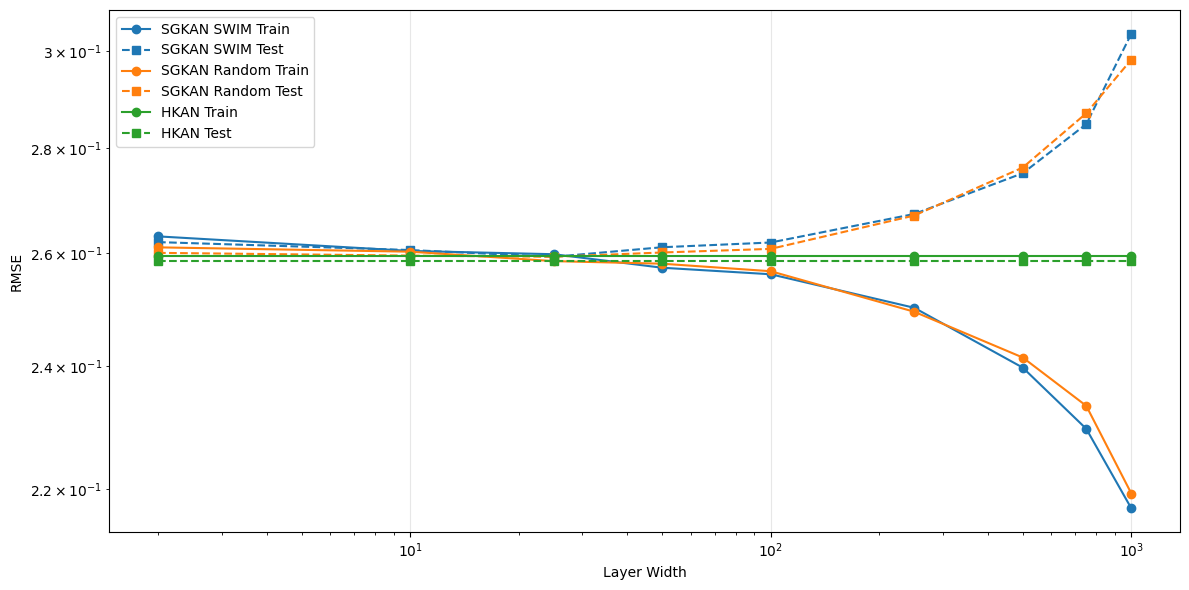

In [73]:
plot_hypothesis_1_results(tf4_hypothesis_1_results_df)

In [74]:
tf4_hypothesis_1_results_df

,Unnamed: 0,layer_width,sgkan_swim_train_rmse,sgkan_swim_test_rmse,sgkan_random_train_rmse,sgkan_random_test_rmse,hkan_train_rmse,hkan_test_rmse
0,0,2,0.2630895687,0.2620253931,0.2610528239,0.2600351612,0.2594232852,0.2584713406
1,1,10,0.2603948392,0.2605567767,0.2602528714,0.2595279873,0.2594232852,0.2584713406
2,2,25,0.2597863919,0.2593097685,0.2585181185,0.2593200103,0.2594232852,0.2584713406
3,3,50,0.2573097607,0.2610734861,0.2580460983,0.2601030881,0.2594232852,0.2584713406
4,4,100,0.2561209311,0.2619499260,0.2566744475,0.2607686081,0.2594232852,0.2584713406
5,5,250,0.2501085962,0.2672997193,0.2494078777,0.2670062119,0.2594232852,0.2584713406
6,6,500,0.2397188318,0.2751354121,0.2414433479,0.2762453808,0.2594232852,0.2584713406
7,7,750,0.2295442523,0.2848786119,0.2333145000,0.2870801894,0.2594232852,0.2584713406
8,8,1000,0.2169582708,0.3037269383,0.2192599854,0.2982157076,0.2594232852,0.2584713406


### Explore Feature importances and Layers

Examine how well each input feature is being captured by the first layer of the best model. This helps us understand which input dimensions are most important and how the model processes the input space.

In [75]:
best_tf4_configs

[{'layer_width': 750,
  'num_inducing': 100,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 100,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=750, D_in=10)
[fit_layer] local-window method counts over 7500 edges: {'interval_capped': 3904, 'interval': 3226, 'knn_fallback': 370}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=750)
[fit_layer] local-window method counts over 750 edges: {'interval': 339, 'interval_capped': 373, 'knn_fallback': 38}


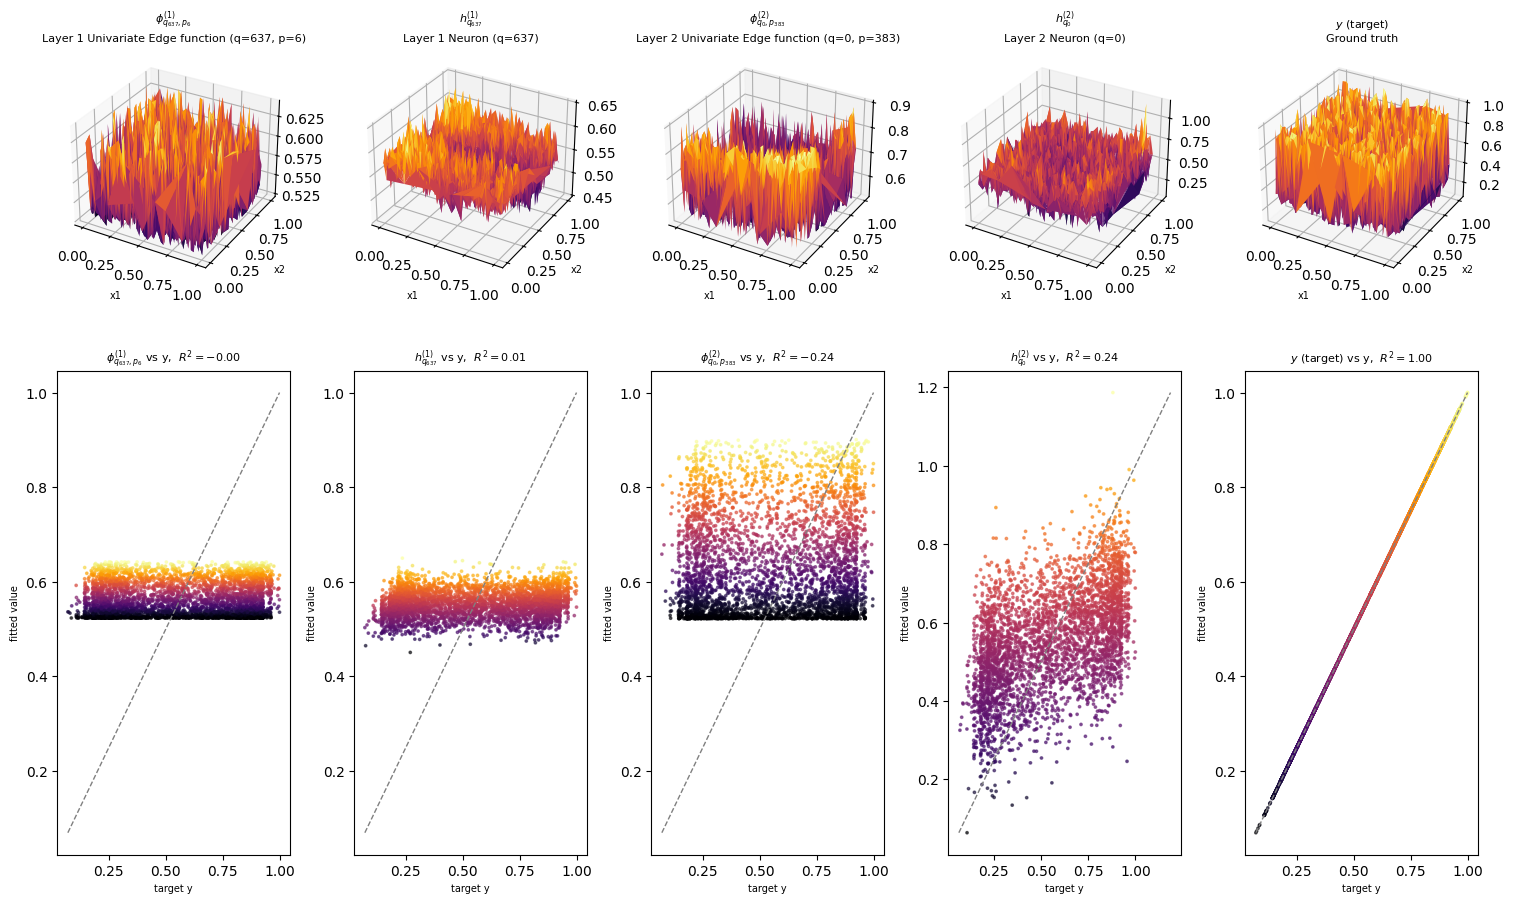

In [76]:
best_tf4_sgkan_stages, best_tf4_sgkan_ytrain_hat, best_tf4_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf4_x_train, tf4_y_train, best_tf4_configs)
visualize.plot_model_stages(tf4_x_train, tf4_y_train, best_tf4_sgkan_stages, block_idx="random", seed=0)

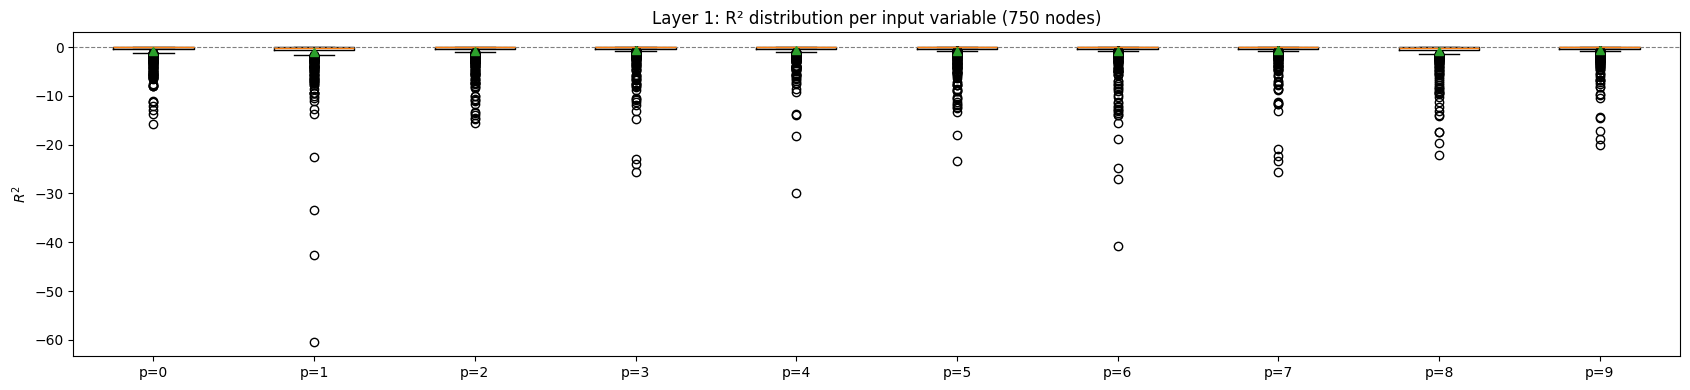

In [77]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf4_sgkan_stages, tf4_y_train)

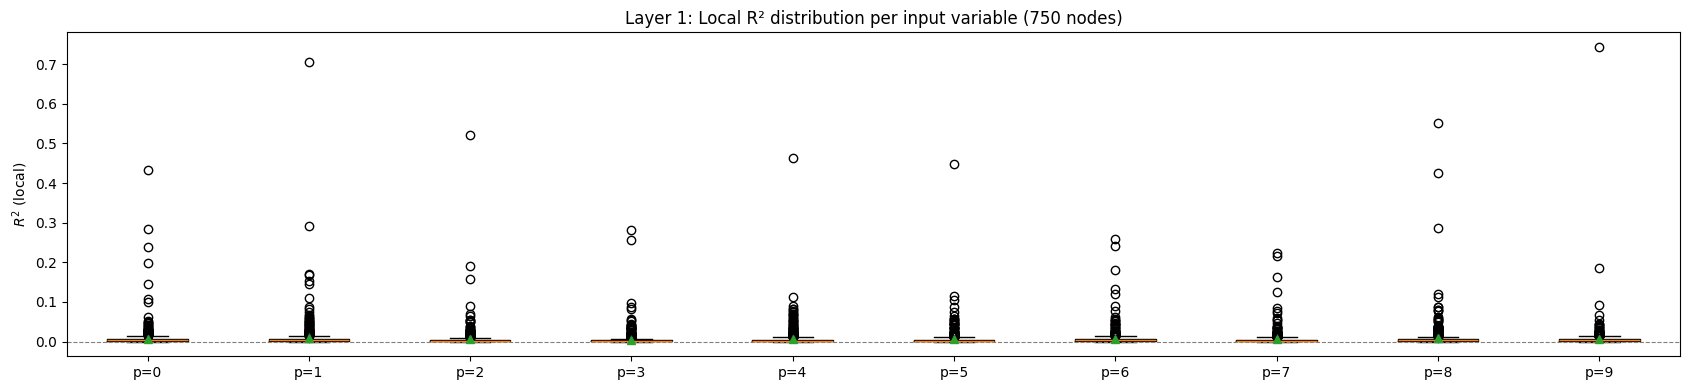

In [78]:
plot_first_layer_local_edge_r2_summary(best_tf4_sgkan_layer_neurons)

## TF5

For TF5, we'll find the best SGKAN configuration through hyperparameter optimization, then run a robustness test with 50 random seeds to compare against our HKAN reproduction, configured with the paper's best reported hyperparameters. We'll also explore how layer width impacts performance and which input features matter most.

### Sanity Check

Sanity check that the model runs without errors. This serves as a basic test before moving to optimization and comparison experiments.

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=100, D_in=2)
[fit_layer] local-window method counts over 200 edges: {'interval_capped': 99, 'interval': 93, 'knn_fallback': 8}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=100)
[fit_layer] local-window method counts over 100 edges: {'interval_capped': 80, 'interval': 19, 'knn_fallback': 1}
TF5 SGKAN train R2: 0.9621454225029806


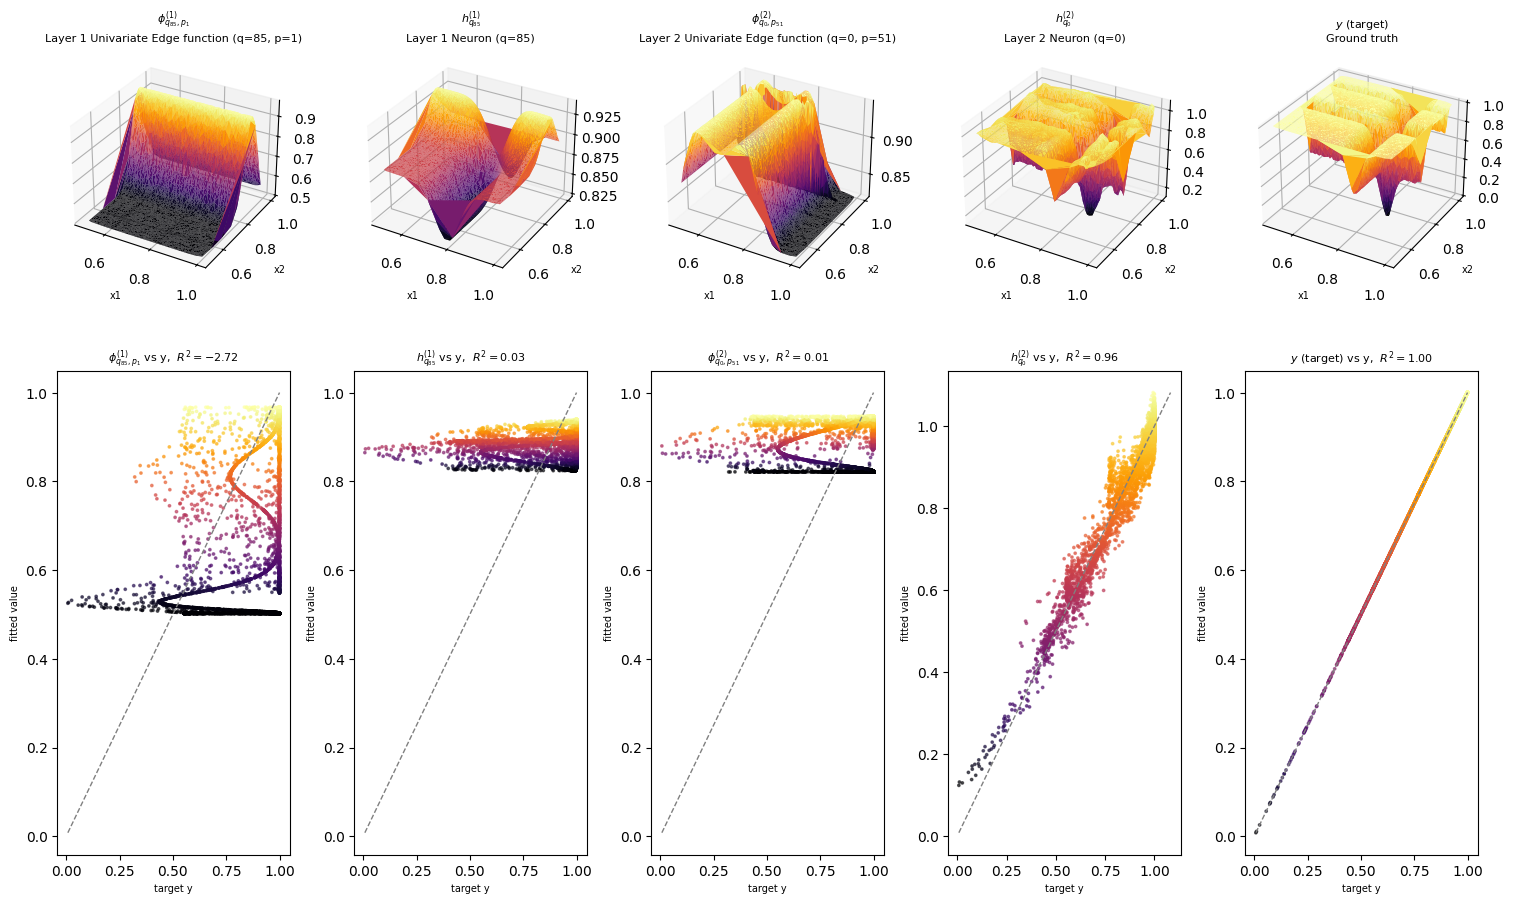

In [79]:
tf5_sgkan_layer_swim_configs = [
    {"layer_width": 100, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
    {"layer_width": 1, "num_inducing": 75, "pair_selection_strategy": "swim", "alpha_edge": 1, "alpha_neuron": 0,
     "max_local_points": 1000, "kernel_type": "rbf", "seed": random_seed, "sigma_scale": 1},
]
# A stage item in stages list consists of (layer_idx, phi[q, p, :] edge function results, layer_output) 
tf5_sgkan_stages, tf5_sgkan_ytrain_hat, tf5_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf5_x_train, tf5_y_train, tf5_sgkan_layer_swim_configs)
print("TF5 SGKAN train R2:", r2_score(tf5_y_train, tf5_sgkan_ytrain_hat))

visualize.plot_model_stages(tf5_x_train, tf5_y_train, tf5_sgkan_stages, block_idx="random", seed=0)

In [80]:
tf5_sgkan_model = sgkan_model.SGKANModel(tf5_sgkan_layer_swim_configs).fit(tf5_x_train, tf5_y_train)

tf5_sgkan_results = em.evaluate(
    tf5_sgkan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)
em.print_results(tf5_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=100, D_in=2)
[fit_layer] local-window method counts over 200 edges: {'interval_capped': 99, 'interval': 93, 'knn_fallback': 8}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=100)
[fit_layer] local-window method counts over 100 edges: {'interval_capped': 80, 'interval': 19, 'knn_fallback': 1}
[SGKANModel.fit] Total fit duration: 3.2575s
Metric          Train                Test                
-------------------------------------------------------
MAE             2.461493e-02         2.540488e-02        
RMSE            3.447421e-02         3.555841e-02        
-------------------------------------------------------
Inference (s)   1.115273             2.045382            


### Optuna - Parameter Search

Find the best layer configuration for TF5 dataset.

In [81]:
tf5_result = sps.study_optuna_sgkan(
    "tf5", tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test,
    n_trials=375
)

Results found for tf5. Loading from data/tf5_sgkan_optuna_search.csv
Best Validation RMSE:   0.000187550693177
Best Test RMSE:          0.001230334676733
Best layer_width:        1000
Best num_inducing:       50
Best alpha_edge:         1.000e+00
Best alpha_neuron:       0.000e+00
Best kernel_type:        rbf

All 375 trials:
     number          value  params_layer_width  params_num_inducing  params_alpha_edge  params_alpha_neuron params_kernel_type       val_rmse     test_rmse
0         0   0.0014591474                1000                   50              0.001                    0             matern   0.0014591474           NaN
1         1   0.0126618196                1000                   25              1.000                    0           periodic   0.0126618196           NaN
2         2   0.0059003113                 500                   50             10.000                    0                rbf   0.0059003113           NaN
3         3   0.0211394409                 500  

In [82]:
# Use best parameter configuration to fit an SGKAN model again
best_tf5_configs = tf5_result["layer_configs"]
best_tf5_configs

[{'layer_width': 1000,
  'num_inducing': 50,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 50,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

In [83]:
tf5_sgkan_optuna_df = pd.read_csv("data/tf5_sgkan_optuna_search.csv")
tf5_sgkan_optuna_df.sort_values("val_rmse").head(5)

,number,value,datetime_start,datetime_complete,duration,params_alpha_edge,params_alpha_neuron,params_kernel_type,params_layer_width,params_num_inducing,...,fit_duration_sec,kernel_type,user_attrs_layer_width,user_attrs_num_inducing,sigma_scale,val_rmse,system_attrs_grid_id,system_attrs_search_space,state,test_rmse
207,207,0.0001875507,2026-08-06 23:00:40.564401,2026-08-06 23:00:58.132191,17.567790,1.000,0,rbf,1000,50,...,16.041655916,rbf,1000,50,1,0.0001875507,207,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,0.0012303347
341,341,0.0003012967,2026-08-06 23:28:05.679946,2026-08-06 23:28:40.237560,34.557614,0.001,0,rbf,1000,100,...,32.231201041,rbf,1000,100,1,0.0003012967,341,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
46,46,0.0005518841,2026-08-06 22:31:14.869332,2026-08-06 22:31:24.297717,9.428385,1.000,0,matern,750,25,...,8.756637250,matern,750,25,1,0.0005518841,46,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
334,334,0.0006190977,2026-08-06 23:26:40.259308,2026-08-06 23:27:05.656791,25.397483,10.000,0,matern,1000,50,...,23.286564875,matern,1000,50,1,0.0006190977,334,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN
285,285,0.0006386337,2026-08-06 23:14:47.911630,2026-08-06 23:15:26.044923,38.133293,0.001,0,rbf,750,100,...,35.175436500,rbf,750,100,1,0.0006386337,285,"{'alpha_edge': [0, 0.001, 0.1, 1, 10], 'alpha_...",COMPLETE,NaN


In [84]:
best_tf5_sgkan_model = sgkan_model.SGKANModel(best_tf5_configs).fit(tf5_x_train, tf5_y_train)

best_tf5_sgkan_results = em.evaluate(
    best_tf5_sgkan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)
em.print_results(best_tf5_sgkan_results)

[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1094, 'interval': 881, 'knn_fallback': 25}
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 811, 'interval': 182, 'knn_fallback': 7}
[SGKANModel.fit] Total fit duration: 19.7849s
Metric          Train                Test                
-------------------------------------------------------
MAE             3.544626e-04         5.664649e-04        
RMSE            5.326688e-04         1.230335e-03        
-------------------------------------------------------
Inference (s)   7.143265             14.416785           


In [85]:
# Try best parameter configuration but without SWIM (random projections) this time
# Aim is to see if using SWIM matters
random_best_tf5_configs = copy.deepcopy(best_tf5_configs)
for i in random_best_tf5_configs:
    i['pair_selection_strategy'] = "random"
random_best_tf5_configs, best_tf5_configs

([{'layer_width': 1000,
   'num_inducing': 50,
   'pair_selection_strategy': 'random',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 50,
   'pair_selection_strategy': 'random',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}],
 [{'layer_width': 1000,
   'num_inducing': 50,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1},
  {'layer_width': 1,
   'num_inducing': 50,
   'pair_selection_strategy': 'swim',
   'alpha_edge': 1.0,
   'alpha_neuron': 0.0,
   'max_local_points': 1000,
   'kernel_type': 'rbf',
   'seed': 0,
   'sigma_scale': 1}])

In [86]:
random_best_tf5_sgkan_model = sgkan_model.SGKANModel(random_best_tf5_configs).fit(tf5_x_train, tf5_y_train)

random_best_tf5_sgkan_results = em.evaluate(
    random_best_tf5_sgkan_model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test
)
em.print_results(random_best_tf5_sgkan_results)

[fit_layer] pair_selection_strategy = 'random' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1293, 'knn_fallback': 30, 'interval': 677}
[fit_layer] pair_selection_strategy = 'random' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 682, 'interval': 307, 'knn_fallback': 11}
[SGKANModel.fit] Total fit duration: 24.7639s
Metric          Train                Test                
-------------------------------------------------------
MAE             4.386941e-04         7.291172e-04        
RMSE            6.688014e-04         2.238577e-03        
-------------------------------------------------------
Inference (s)   6.968241             13.218609           


### 50 seed results

Run the best SGKAN model 50 times with different random seeds to compute median and IQR of RMSE, matching the methodology from HKAN's paper for fair comparison. This statistical approach accounts for the randomness in pair selection and provides a robust measure of model performance variability.

In [87]:
tf5_50_runs_path = "data/tf5_sgkan_50_run_results.csv"

if os.path.exists(tf5_50_runs_path):
    tf5_50_runs_df = pd.read_csv("data/tf5_sgkan_50_run_results.csv")
else:
    tf5_50_runs = run_sgkan_seed_experiments(tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test, best_tf5_configs, n_runs=50)
    tf5_50_runs_df = create_export_seed_results(tf5_50_runs, "tf5_sgkan_50_run_results")

tf5_50_runs_df.head()

,seed,train_mae,train_rmse,train_inference_time_secs,test_mae,test_rmse,test_inference_time_secs
0,0,0.0003544626,0.0005326688,7.664406500,0.0005664649,0.0012303347,14.401798167
1,1,0.0003479253,0.0005199217,7.109016041,0.0006643318,0.0028935192,14.100602333
2,2,0.0004575715,0.0006421849,7.963815417,0.0007291917,0.0024873827,15.290219875
3,3,0.0008492616,0.0013203059,8.171813541,0.0014316432,0.0044057665,16.410680708
4,4,0.0004190386,0.0006310671,8.972959625,0.0007362570,0.0032447847,17.103783792


In [88]:
summarize_metrics(tf5_50_runs_df, "SGKAN SWIM")

{'model': 'SGKAN SWIM',
 'train_rmse_median': 0.0006154461406828501,
 'train_rmse_iqr': 0.0006473727233658249,
 'test_rmse_median': 0.00228778627928255,
 'test_rmse_iqr': 0.0016489566705463748}

### Hypothesis 1

Increasing layer width (other parameters are constant) vs. RMSE for different models HKAN, SGKAN swim and SGKAN random

Compare how increasing the first layer width affects performance across SGKAN (SWIM), SGKAN (random), and HKAN. All other parameters stay fixed to isolate the width effect. The goal is to understand whether wider layers consistently improve predictions and if this trend differs between the algorithms.

In [89]:
# Best TF5 HKAN configuration from the paper
tf5_hkan_layer_configs = [
    dict(layer=0, n_vars_out=912, n_basis=23, centers="random", basis_fn=Tanh(s=50), expanding_base_regressor=Ridge(alpha=0.01)),
    dict(layer=1, n_vars_out=1, n_basis=1, centers="equally_spaced", basis_fn=Identity(), expanding_base_regressor=None),
]

In [90]:
tf5_hypothesis_1_path = "data/tf5_hypothesis_1_results_df.csv"

if os.path.exists(tf5_hypothesis_1_path):
    tf5_hypothesis_1_results_df = pd.read_csv("data/tf5_hypothesis_1_results_df.csv")
else:
    # Define layer widths
    layer_widths = [2, 10, 25, 50, 100, 250, 500, 750, 1000]

    # Results storage
    results = {
        'sgkan_swim': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'sgkan_random': {'widths': [], 'train_rmse': [], 'test_rmse': []},
        'hkan': {'widths': [], 'train_rmse': [], 'test_rmse': []}
    }

    # SGKAN with SWIM
    print("Testing SGKAN with SWIM pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf5_configs]
        config[0]['layer_width'] = width
        model = sgkan_model.SGKANModel(config).fit(tf5_x_train, tf5_y_train)
        eval_results = em.evaluate(model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
        results['sgkan_swim']['widths'].append(width)
        results['sgkan_swim']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_swim']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # SGKAN with random pair selection
    print("\nTesting SGKAN with random pair selection...")
    for width in layer_widths:
        config = [c.copy() for c in best_tf5_configs]
        config[0]['pair_selection_strategy'] = 'random'
        config[0]['layer_width'] = width
        config[1]['pair_selection_strategy'] = 'random'
        model = sgkan_model.SGKANModel(config).fit(tf5_x_train, tf5_y_train)
        eval_results = em.evaluate(model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
        results['sgkan_random']['widths'].append(width)
        results['sgkan_random']['train_rmse'].append(eval_results['train']['rmse'])
        results['sgkan_random']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # HKAN with best config
    print("\nTesting HKAN...")
    for width in layer_widths:
        config = [c.copy() for c in tf5_hkan_layer_configs]
        config[0]['n_vars_out'] = width
        model = utils.build_hkan_model_from_configs(config, tqdm_disable=True)
        utils.fit_hkan(model, tf5_x_train, tf5_y_train)
        eval_results = em.evaluate(model, tf5_x_train, tf5_y_train, tf5_x_test, tf5_y_test)
        results['hkan']['widths'].append(width)
        results['hkan']['train_rmse'].append(eval_results['train']['rmse'])
        results['hkan']['test_rmse'].append(eval_results['test']['rmse'])
        print(f"  Width {width}: Train RMSE={eval_results['train']['rmse']:.6e}, Test RMSE={eval_results['test']['rmse']:.6e}")

    # Display results
    tf5_hypothesis_1_results_df = pd.DataFrame({
        'layer_width': layer_widths,
        'sgkan_swim_train_rmse': results['sgkan_swim']['train_rmse'],
        'sgkan_swim_test_rmse': results['sgkan_swim']['test_rmse'],
        'sgkan_random_train_rmse': results['sgkan_random']['train_rmse'],
        'sgkan_random_test_rmse': results['sgkan_random']['test_rmse'],
        'hkan_train_rmse': results['hkan']['train_rmse'],
        'hkan_test_rmse': results['hkan']['test_rmse']
    })
    tf5_hypothesis_1_results_df.to_csv("data/tf5_hypothesis_1_results_df.csv")

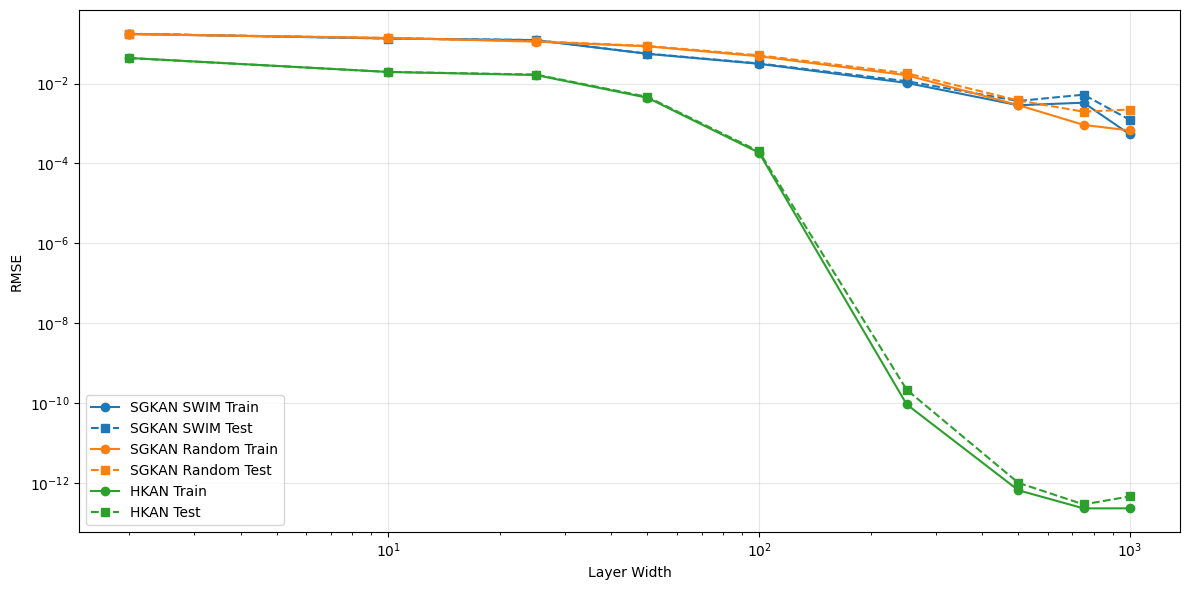

In [91]:
plot_hypothesis_1_results(tf5_hypothesis_1_results_df)

In [92]:
tf5_hypothesis_1_results_df

,Unnamed: 0,layer_width,sgkan_swim_train_rmse,sgkan_swim_test_rmse,sgkan_random_train_rmse,sgkan_random_test_rmse,hkan_train_rmse,hkan_test_rmse
0,0,2,0.1752523906,0.1772748196,0.1729328081,0.1750342162,4.3849197462e-02,4.3548397140e-02
1,1,10,0.1348603833,0.1346299552,0.1387088241,0.1389774793,1.9560166616e-02,1.9611767286e-02
2,2,25,0.1225806518,0.1233142290,0.1124346593,0.1152760487,1.6415402108e-02,1.6830933965e-02
3,3,50,0.0555545582,0.0563760235,0.0856136542,0.0875913105,4.4213981678e-03,4.6426776186e-03
4,4,100,0.0312809810,0.0319592326,0.0483029996,0.0510438614,1.8570823303e-04,1.9977532142e-04
5,5,250,0.0103980811,0.0115087670,0.0162204842,0.0181433504,9.2484792191e-11,2.1547613527e-10
6,6,500,0.0028677049,0.0036678253,0.0028873230,0.0037855780,6.5436451469e-13,1.0032765193e-12
7,7,750,0.0033233712,0.0052819257,0.0009233708,0.0019773005,2.2954721058e-13,2.8840089467e-13
8,8,1000,0.0005326688,0.0012303347,0.0006688014,0.0022385771,2.3059286159e-13,4.5875125699e-13


### Explore Feature importances and Layers

Examine how well each input feature is being captured by the first layer of the best model. This helps us understand which input dimensions are most important and how the model processes the input space.

In [93]:
best_tf5_configs

[{'layer_width': 1000,
  'num_inducing': 50,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1},
 {'layer_width': 1,
  'num_inducing': 50,
  'pair_selection_strategy': 'swim',
  'alpha_edge': 1.0,
  'alpha_neuron': 0.0,
  'max_local_points': 1000,
  'kernel_type': 'rbf',
  'seed': 0,
  'sigma_scale': 1}]

[build_sgkan_stack] Layer 1: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1000, D_in=2)
[fit_layer] local-window method counts over 2000 edges: {'interval_capped': 1094, 'interval': 881, 'knn_fallback': 25}
[build_sgkan_stack] Layer 2: pair_selection_strategy = 'swim'
[fit_layer] pair_selection_strategy = 'swim' (layer_width=1, D_in=1000)
[fit_layer] local-window method counts over 1000 edges: {'interval_capped': 811, 'interval': 182, 'knn_fallback': 7}


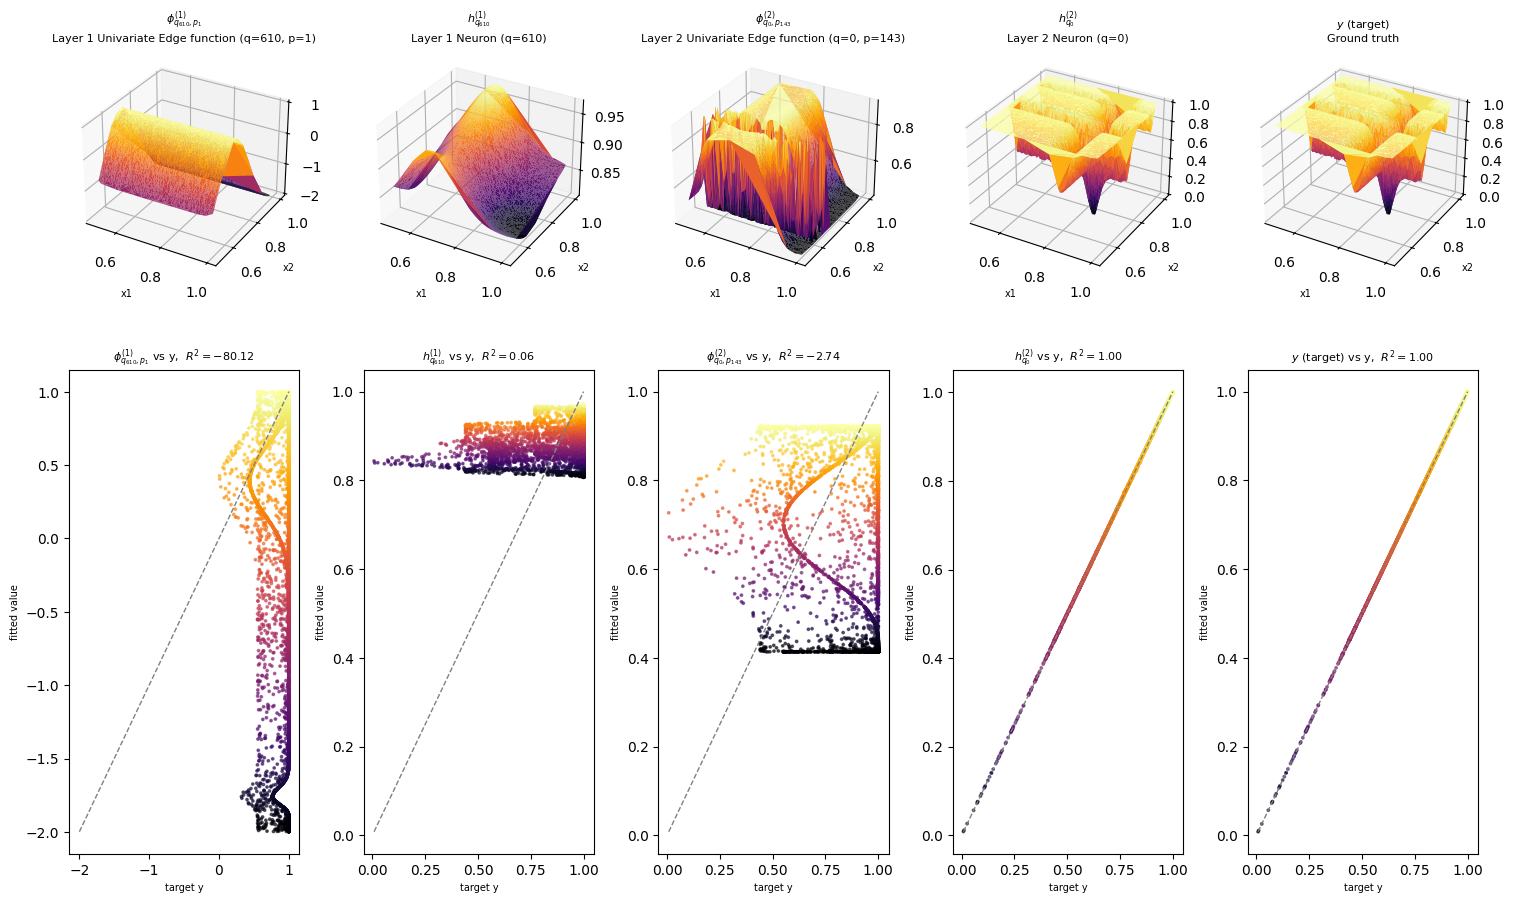

In [94]:
best_tf5_sgkan_stages, best_tf5_sgkan_ytrain_hat, best_tf5_sgkan_layer_neurons = sgkan_model.build_sgkan_stack(tf5_x_train, tf5_y_train, best_tf5_configs)
visualize.plot_model_stages(tf5_x_train, tf5_y_train, best_tf5_sgkan_stages, block_idx="random")

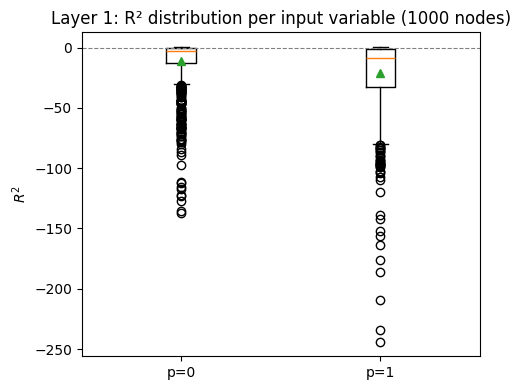

In [95]:
visualize.plot_first_layer_featurewise_r2_summary(best_tf5_sgkan_stages, tf5_y_train)

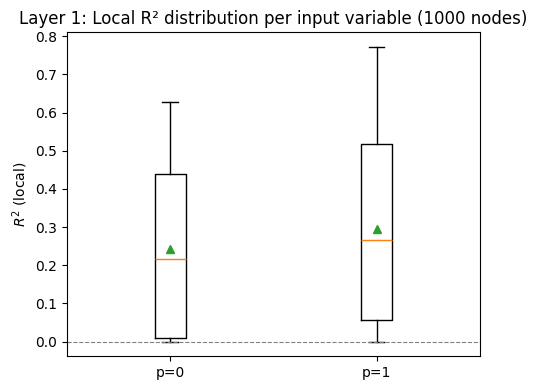

In [96]:
plot_first_layer_local_edge_r2_summary(best_tf5_sgkan_layer_neurons)